# M02 - Clinical EDA

**Sections**
1. Dataset overview - completeness, most complete columns, continuous outliers, categorical checks
2. Population characterization - demographics, MRI scar variables, risk factors, infarction history, cardiac function, devices, arrhythmias, follow-up
3. Risk factors - prevalence, marked for clinical review
4. Scar geometry - continuous metrics with and without outlier removal
5. Correlation matrix - numeric variables, excluding direct gram-vs-percent scar duplicates
6. Subgroup comparisons - sex-specific age/scar patterns and septum/LVEF relationship

## 0 · Setup

In [1]:
import json
import sys
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

MODULE_DIR = Path('..').resolve()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))
from src.clinical_data import load, COLUMN_GROUPS, CATEGORICAL_LABELS, CLINICAL_REVIEW_NOTES
from src.data_loading import scan

CSV_PATH = Path('C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv')
HD_ROOT = Path('F:/RM_TEKNON_DEVELOP')
RESULTS_DIR = MODULE_DIR / 'results' / 'M02'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 125,
    'savefig.dpi': 300,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.linewidth': 0.7,
    'font.size': 11,
    'axes.titleweight': 'semibold',
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.frameon': False,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
TFG_COLORS = {
    'primary': '#256D85', 'secondary': '#D9822B', 'positive': '#2E8B57',
    'neutral': '#B8C0C8', 'missing': '#C44E52', 'male': '#256D85',
    'female': '#B35C9E', 'line': '#263238', 'text': '#263238',
}
PAL = list(TFG_COLORS.values())
HIST_COLOR = TFG_COLORS['primary']
MEDIAN_COLOR = TFG_COLORS['secondary']
SEG_COLOR = TFG_COLORS['secondary']
NO_SEG_COLOR = TFG_COLORS['primary']

VARIABLE_INFO = {
    'age': ('Age (years)', 'Patient age at the time of MRI'),
    'sex': ('Sex', 'Registry code: 1 = male, 2 = female'),
    'mi_to_mri_months': ('Delay from MI to MRI (months)', 'Months between infarction and MRI'),
    'lv_mass_g': ('LV mass (g)', 'Left ventricular myocardial mass in grams'),
    'bz_core_g': ('Total scar mass (g)', 'Border zone + core scar mass in grams'),
    'bz_core_pct': ('Total scar (% LV mass)', 'Border zone + core scar as a percentage of LV mass'),
    'bz_g': ('Border-zone mass (g)', 'Heterogeneous border zone mass in grams'),
    'bz_pct': ('Border zone (% LV mass)', 'Border zone as a percentage of LV mass'),
    'core_g': ('Core scar mass (g)', 'Dense core scar mass in grams'),
    'core_pct': ('Core scar (% LV mass)', 'Dense core scar as a percentage of LV mass'),
    'channel_mass_g': ('Channel mass (g)', 'Mass of identified conduction channels inside the scar'),
    'lvef_pct': ('LVEF (%)', 'Left ventricular ejection fraction'),
    'lvedd_mm': ('LV end-diastolic diameter (mm)', 'Diastolic LV diameter'),
    'lvesd_mm': ('LV end-systolic diameter (mm)', 'Systolic LV diameter'),
    'lvedv_ml': ('LV end-diastolic volume (mL)', 'LV volume at end-diastole'),
    'lvedv_index': ('LV end-diastolic volume index', 'Indexed LV end-diastolic volume'),
    'lvesv_ml': ('LV end-systolic volume (mL)', 'LV volume at end-systole'),
    'lvesv_index': ('LV end-systolic volume index', 'Indexed LV end-systolic volume'),
    'la_mm': ('Left atrial diameter (mm)', 'Left atrial size'),
    'septum_mm': ('Septum thickness (mm)', 'Interventricular septum thickness'),
    'post_wall_mm': ('Posterior wall thickness (mm)', 'Posterior LV wall thickness'),
    'enhancement_territory': ('Enhancement territory', 'Main coronary territory with scar'),
    'enhancement_distribution': ('Enhancement distribution', 'Scar distribution pattern across the wall'),
    'enhancement_grade': ('Enhancement grade', 'Semiquantitative enhancement extent/intensity score'),
    'channels': ('Channels', '1 = conduction channels identified within the scar'),
    'mri_type': ('MRI type', 'Acquisition / MRI study type recorded in the registry'),
    'has_segmentation': ('Has MRI segmentation', 'Patient has an ADAS3D scar segmentation available'),
}


def variable_label(col):
    return VARIABLE_INFO.get(col, (col.replace('_', ' ').title(), ''))[0]


def variable_description(col):
    return VARIABLE_INFO.get(col, (col.replace('_', ' ').title(), ''))[1]


def variable_title(col):
    desc = variable_description(col)
    if desc:
        return f"{variable_label(col)}\n{desc}"
    return variable_label(col)


def normalize_patient_id(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.endswith('.0'):
        text = text[:-2]
    return text


def zscore(series):
    s = pd.to_numeric(series, errors='coerce')
    std = s.std()
    if pd.isna(std) or std == 0:
        return s * np.nan
    return (s - s.mean()) / std


df = load(CSV_PATH)
df['patient_id_norm'] = df['patient_id'].map(normalize_patient_id)
print(f'Loaded: {len(df)} patients, {len(df.columns)} columns')


SEX_LABELS = CATEGORICAL_LABELS.get('sex', {1: 'Male', 2: 'Female'})
SEX_COLORS = {1: TFG_COLORS['male'], 2: TFG_COLORS['female']}
VALUE_LABELS = {
    'sex': SEX_LABELS,
    'has_segmentation': {False: 'No segmentation', True: 'Segmentation'},
    'hta': {0: 'No hypertension', 1: 'Hypertension'},
    'dlp': {0: 'No dyslipidaemia', 1: 'Dyslipidaemia'},
    'dm': {0: 'No diabetes', 1: 'Diabetes'},
    'smoking': {0: 'Non-smoker / not recorded as smoker', 1: 'Smoking'},
    'afib': {0: 'No atrial fibrillation', 1: 'Atrial fibrillation'},
    'mi_yn': {0: 'No previous MI', 1: 'Previous MI'},
    'channels': {0: 'No channels', 1: 'Channels present'},
}

def display_label(col, value):
    if pd.isna(value): return 'Unknown'
    labels = VALUE_LABELS.get(col, {})
    return labels.get(value, labels.get(str(value), str(value)))

def apply_tfg_style(ax, xgrid=False):
    ax.grid(True, axis='x' if xgrid else 'y', alpha=0.18, linewidth=0.7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#C8CDD2'); ax.spines['bottom'].set_color('#C8CDD2')
    ax.tick_params(labelsize=9, colors=TFG_COLORS['text'])
    return ax

def add_panel_label(ax, text, loc='upper_right'):
    x,y,ha,va = (0.97,0.94,'right','top') if loc=='upper_right' else (0.03,0.94,'left','top')
    ax.text(x,y,text,transform=ax.transAxes,ha=ha,va=va,fontsize=9.5,color=TFG_COLORS['text'],
            bbox=dict(boxstyle='round,pad=0.28', facecolor='white', edgecolor='#D7DCE0', alpha=0.92), zorder=5)

def iqr_filter(series, k=1.5):
    s = pd.to_numeric(series, errors='coerce').dropna()
    if len(s) < 4: return s
    q1,q3 = s.quantile([0.25,0.75]); iqr=q3-q1
    if pd.isna(iqr) or iqr == 0: return s
    return s[(s >= q1-k*iqr) & (s <= q3+k*iqr)]

def plot_numeric_distribution(ax, values, color=HIST_COLOR, label=None, bins=18):
    vals = pd.to_numeric(values, errors='coerce').dropna()
    if vals.empty:
        ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes); return vals
    ax.hist(vals, bins=min(bins, max(6, int(np.sqrt(len(vals)))+2)), density=True, color=color, alpha=0.22, edgecolor='white', linewidth=0.8, label=label)
    if len(vals) >= 5 and float(vals.std()) > 0:
        xs=np.linspace(float(vals.min()), float(vals.max()), 200); kde=stats.gaussian_kde(vals)(xs)
        ax.plot(xs,kde,color=color,linewidth=2.0)
    med=float(vals.median()); ax.axvline(med,color=MEDIAN_COLOR,linestyle=':',linewidth=1.5)
    add_panel_label(ax, f'n={len(vals)}\nmedian={med:.1f}')
    ax.set_ylabel('Density'); return vals

Loaded: 173 patients, 87 columns


In [2]:
# Identify patients with MRI segmentation from the full ADAS3D scan folder.
# The segmentation cohort is derived directly from the full ADAS3D case scan.
# with an available core-zone surface.
def has_core_segmentation(case):
    p = case.tissue_surfaces.get('core')
    return p is not None and p.exists()

if HD_ROOT.exists():
    all_cases = scan(HD_ROOT)
    seg_ids = {normalize_patient_id(case.patient_id) for case in all_cases if has_core_segmentation(case)}
    segmentation_source = f'ADAS3D scan folder: {HD_ROOT}'
else:
    seg_ids = set()
    segmentation_source = 'No segmentation source found'

df['has_segmentation'] = df['patient_id_norm'].isin(seg_ids)
print(f'Segmentation source: {segmentation_source}')
print(f"Patients with MRI segmentation: {int(df['has_segmentation'].sum())} / {len(df)}")
print(df['has_segmentation'].value_counts())

Segmentation source: ADAS3D scan folder: F:\RM_TEKNON_DEVELOP
Patients with MRI segmentation: 88 / 173
has_segmentation
True     88
False    85
Name: count, dtype: int64


## 1 · Dataset overview

Printed table only — no heatmap.
Shows dtype, n valid, % missing, n unique, and for numeric columns: mean, std, min, max.

In [3]:
rows = []
for col in df.columns:
    s = df[col]
    row = {
        'column':      col,
        'dtype':       str(s.dtype),
        'n_valid':     int(s.notna().sum()),
        'pct_missing': round(s.isna().mean() * 100, 1),
        'n_unique':    int(s.nunique()),
    }
    if pd.api.types.is_numeric_dtype(s) and s.notna().sum() > 0:
        row['mean'] = round(float(s.mean()), 2)
        row['std']  = round(float(s.std()),  2)
        row['min']  = float(s.min())
        row['max']  = float(s.max())
    rows.append(row)

overview = pd.DataFrame(rows).set_index('column')
pd.set_option('display.max_rows', 120)
display(overview)

,dtype,n_valid,pct_missing,n_unique,mean,std,min,max
column,,,,,,,,
inclusion,str,128,26.0,42,NaN,NaN,NaN,NaN
patient_id,str,171,1.2,171,NaN,NaN,NaN,NaN
date_mi,datetime64[us],54,68.8,47,NaN,NaN,NaN,NaN
date_mri,datetime64[us],136,21.4,128,NaN,NaN,NaN,NaN
mri_type,str,159,8.1,10,NaN,NaN,NaN,NaN
diagnosis,str,162,6.4,9,NaN,NaN,NaN,NaN
lv_mass_g,float64,166,4.0,165,120.24,36.82,55.54,283.25
bz_core_g,float64,166,4.0,160,16.64,14.14,1.04,106.50
bz_core_pct,float64,166,4.0,160,13.05,8.02,1.42,51.50


### 1a - Most complete columns

This table ranks columns by availability so the most robust variables for modelling or reporting are visible early.

In [4]:
most_complete = (
    overview.reset_index()
    .assign(pct_complete=lambda x: 100 - x['pct_missing'])
    .sort_values(['pct_complete', 'n_unique', 'column'], ascending=[False, False, True])
    [['column', 'dtype', 'n_valid', 'pct_complete', 'pct_missing', 'n_unique']]
    .reset_index(drop=True)
)
display(most_complete.head(30))
most_complete.to_csv(RESULTS_DIR / '01a_most_complete_columns.csv', index=False)

,column,dtype,n_valid,pct_complete,pct_missing,n_unique
0,has_segmentation,bool,173,100.0,0.0,2
1,patient_id,str,171,98.8,1.2,171
2,patient_id_norm,str,171,98.8,1.2,171
3,channel_mass_g,float64,167,96.5,3.5,102
4,channels,Int64,167,96.5,3.5,2
5,lv_mass_g,float64,166,96.0,4.0,165
6,bz_g,float64,166,96.0,4.0,163
7,bz_pct,float64,166,96.0,4.0,161
8,bz_core_g,float64,166,96.0,4.0,160
9,bz_core_pct,float64,166,96.0,4.0,160


### 1b - Continuous numeric outlier check: scatter vs patient row index

This plot is restricted to continuous numeric variables. Binary and low-cardinality coded variables such as `sex`, `hta`, `dlp`, `dm`, and `channels` are excluded because their scatter plots are not useful for outlier detection.

Continuous numeric variables included in outlier scatter:
['lv_mass_g', 'bz_core_g', 'bz_core_pct', 'bz_g', 'bz_pct', 'core_g', 'core_pct', 'channel_mass_g', 'age', 'lvef_pct', 'lvedd_mm', 'lvesd_mm', 'lvedv_ml', 'lvedv_index', 'lvesv_ml', 'lvesv_index', 'la_mm', 'septum_mm']
Excluded discrete/coded numeric variables:


,column,n_valid,n_unique,reason
0,enhancement_grade,67,4,< 10 unique values
1,post_wall_mm,89,8,< 10 unique values
2,pvc_burden,38,6,< 10 unique values
3,admission_angina,42,2,coded/known categorical
4,admission_hf,41,2,coded/known categorical
5,afib,77,3,coded/known categorical
6,arrhythmic_death_yn,43,1,coded/known categorical
7,biomonitor,48,2,coded/known categorical
8,cardiac_death_yn,43,1,coded/known categorical
9,channels,167,2,coded/known categorical


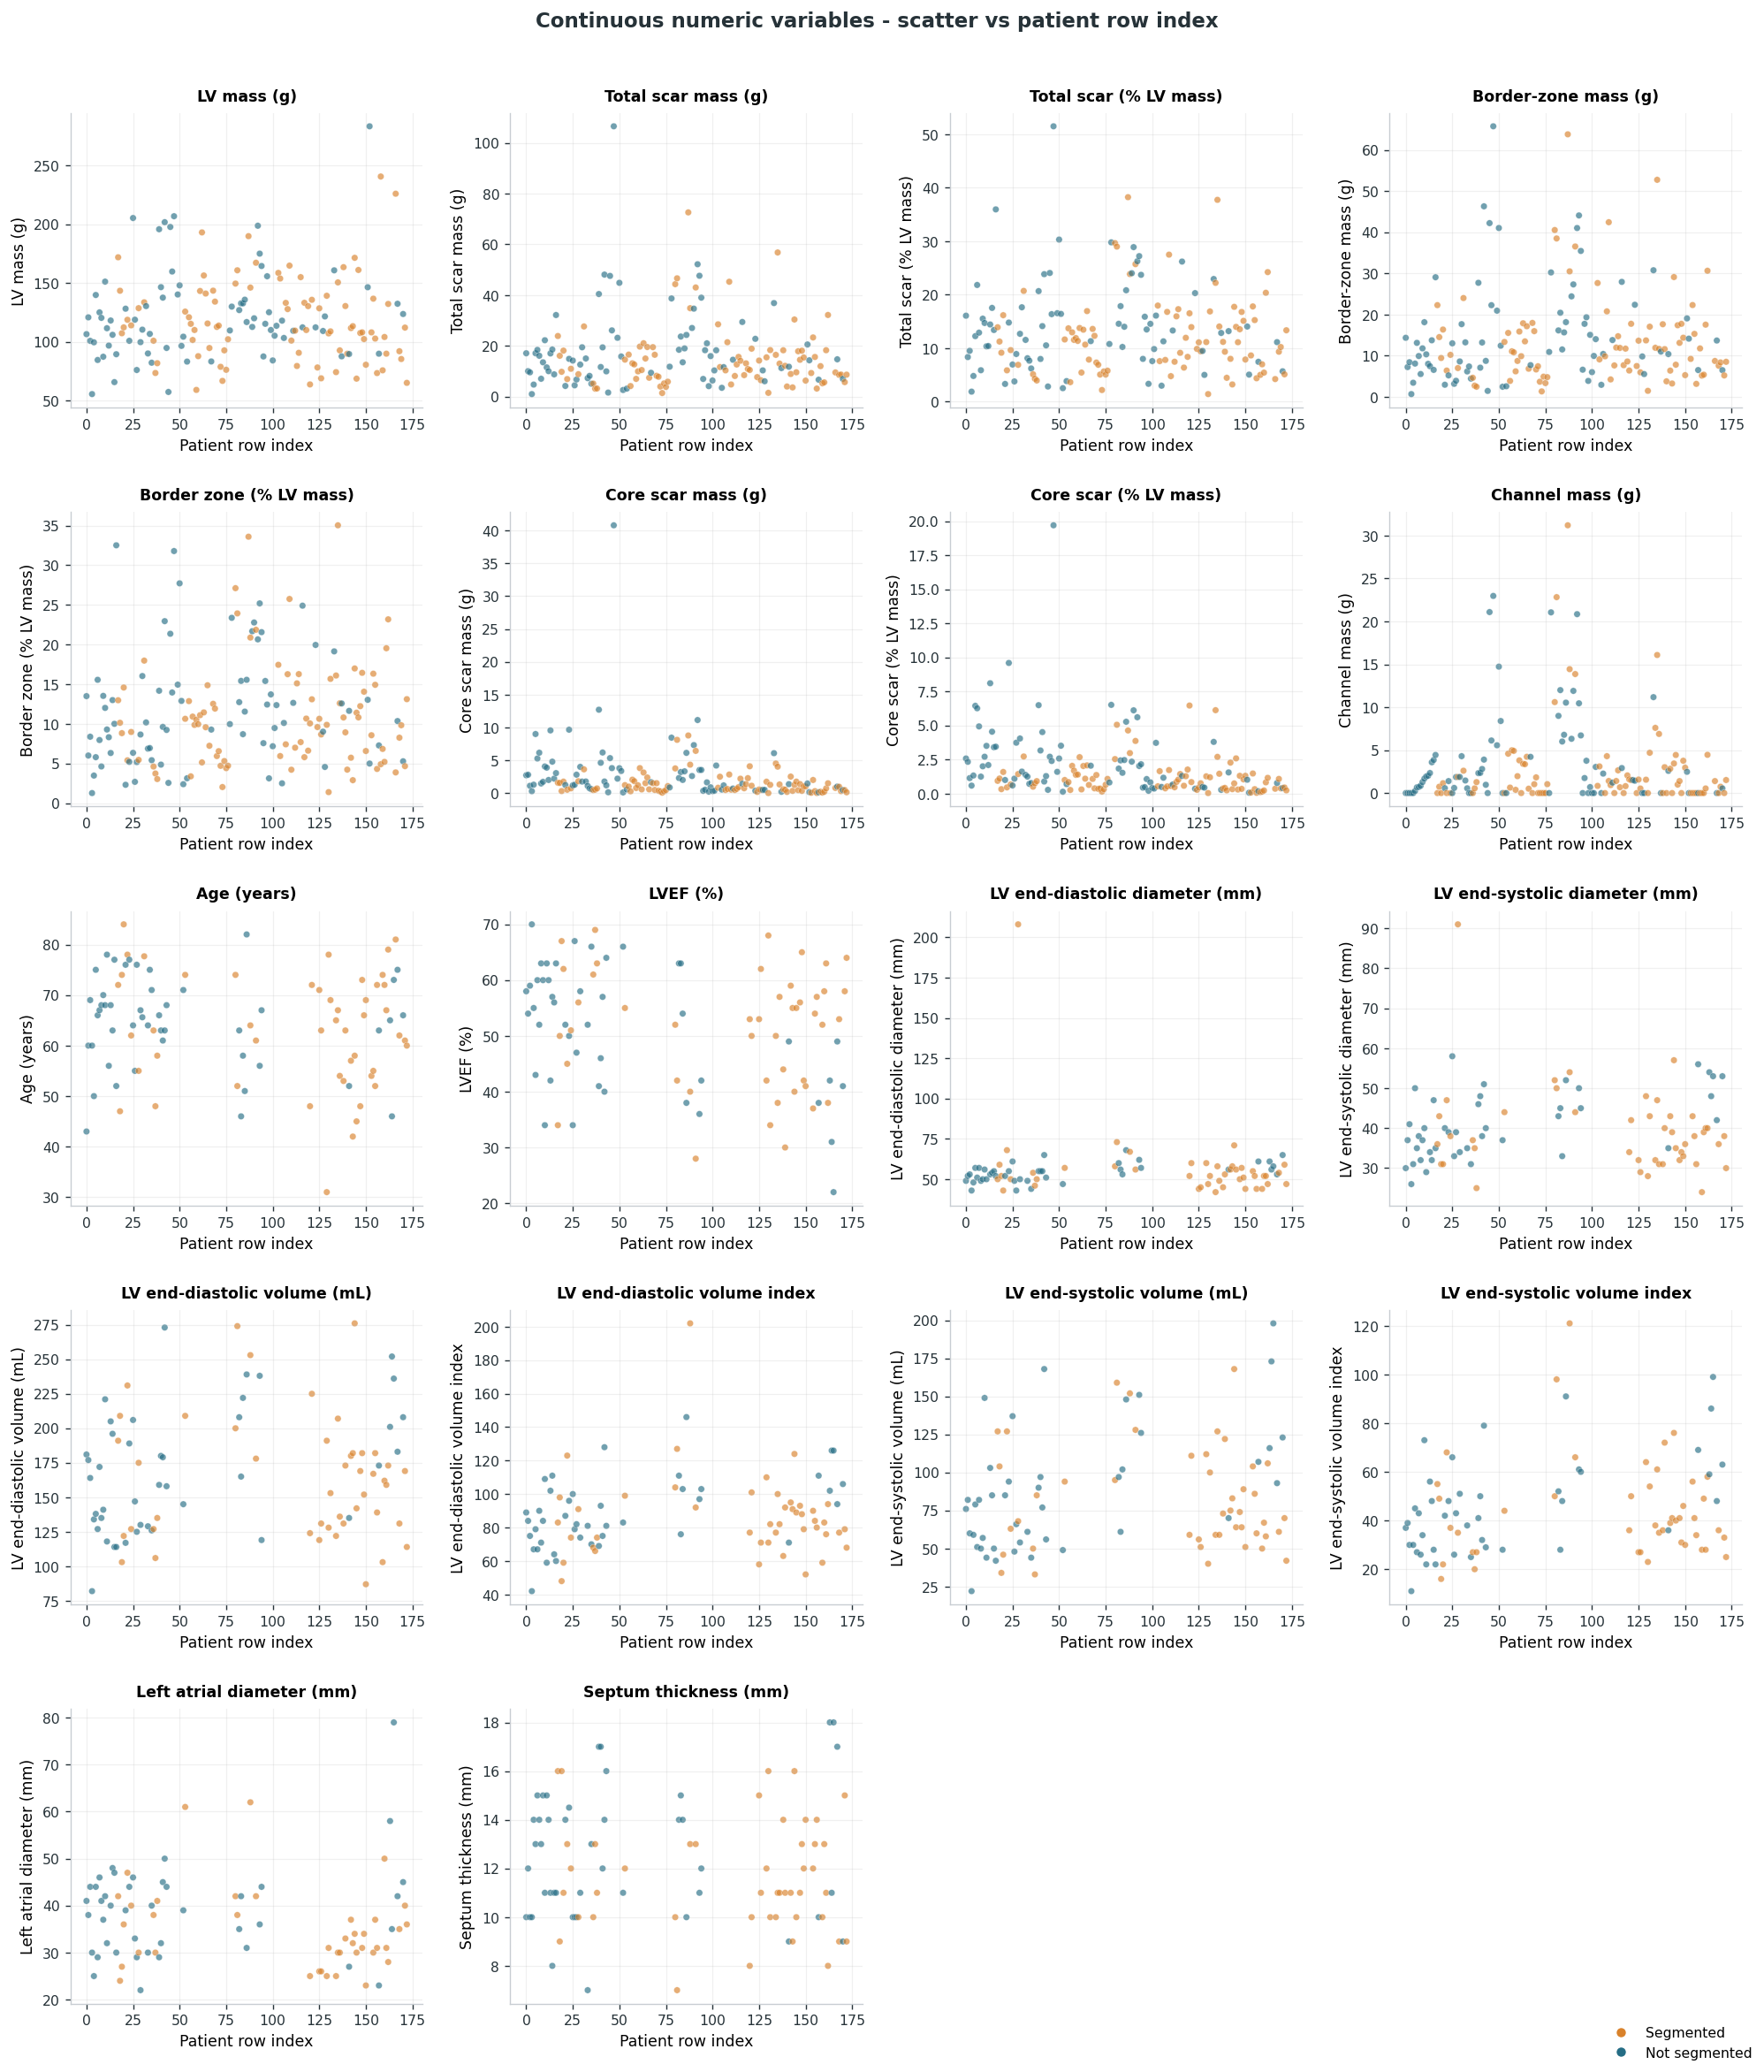

In [5]:
CODED_NUMERIC_COLS = {
    'sex', 'hta', 'dlp', 'dm', 'smoking', 'afib', 'mi_yn', 'channels',
    'device_carrier', 'biomonitor', 'clinical_va', 'inducible_va',
    'icd_therapies', 'va_ablation', 'admission_hf', 'admission_angina',
    'revasc_followup_yn', 'followup_va_yn', 'death_yn', 'cardiac_death_yn',
    'arrhythmic_death_yn', 'nyha', 'nyha_class', 'has_segmentation',
}
MIN_UNIQUE_FOR_CONTINUOUS = 10
numeric_candidates = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and df[c].notna().sum() >= 5 and c not in ('patient_id', 'patient_id_norm')]
num_cols = [c for c in numeric_candidates if c not in CODED_NUMERIC_COLS and df[c].nunique(dropna=True) >= MIN_UNIQUE_FOR_CONTINUOUS]
excluded_discrete = [{'column': c, 'n_valid': int(df[c].notna().sum()), 'n_unique': int(df[c].nunique(dropna=True)), 'reason': 'coded/known categorical' if c in CODED_NUMERIC_COLS else f'< {MIN_UNIQUE_FOR_CONTINUOUS} unique values'} for c in numeric_candidates if c not in num_cols]
print('Continuous numeric variables included in outlier scatter:')
print(num_cols)
print('Excluded discrete/coded numeric variables:')
display(pd.DataFrame(excluded_discrete).sort_values(['reason', 'column']).reset_index(drop=True))
color_map = df['has_segmentation'].map({True: SEG_COLOR, False: NO_SEG_COLOR})
if num_cols:
    n_cols = 4
    n_rows = ceil(len(num_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.8 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for i, col in enumerate(num_cols):
        s = pd.to_numeric(df[col], errors='coerce')
        mask = s.notna()
        axes[i].scatter(s.index[mask], s.values[mask], c=color_map[mask], alpha=0.65, s=18, edgecolor='white', linewidth=0.25)
        axes[i].set_title(variable_label(col), fontsize=10, pad=8)
        axes[i].set_xlabel('Patient row index')
        axes[i].set_ylabel(variable_label(col))
        apply_tfg_style(axes[i])
    for ax in axes[len(num_cols):]: ax.set_visible(False)
    from matplotlib.lines import Line2D
    fig.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=SEG_COLOR,markersize=7,label='Segmented'), Line2D([0],[0],marker='o',color='w',markerfacecolor=NO_SEG_COLOR,markersize=7,label='Not segmented')], loc='lower right', fontsize=9)
    plt.suptitle('Continuous numeric variables - scatter vs patient row index', fontweight='semibold', color=TFG_COLORS['text'])
    plt.tight_layout(rect=(0, 0, 1, 0.97), h_pad=2.0, w_pad=1.4)
    plt.savefig(RESULTS_DIR / '01b_continuous_num_scatter.png', bbox_inches='tight')
    plt.show()

### 1c - Categorical / binary columns - value counts including unknown

Bars show the most frequent recorded categories. Missing / empty values are grouped as **Unknown** so they are visible instead of disappearing from the plot.



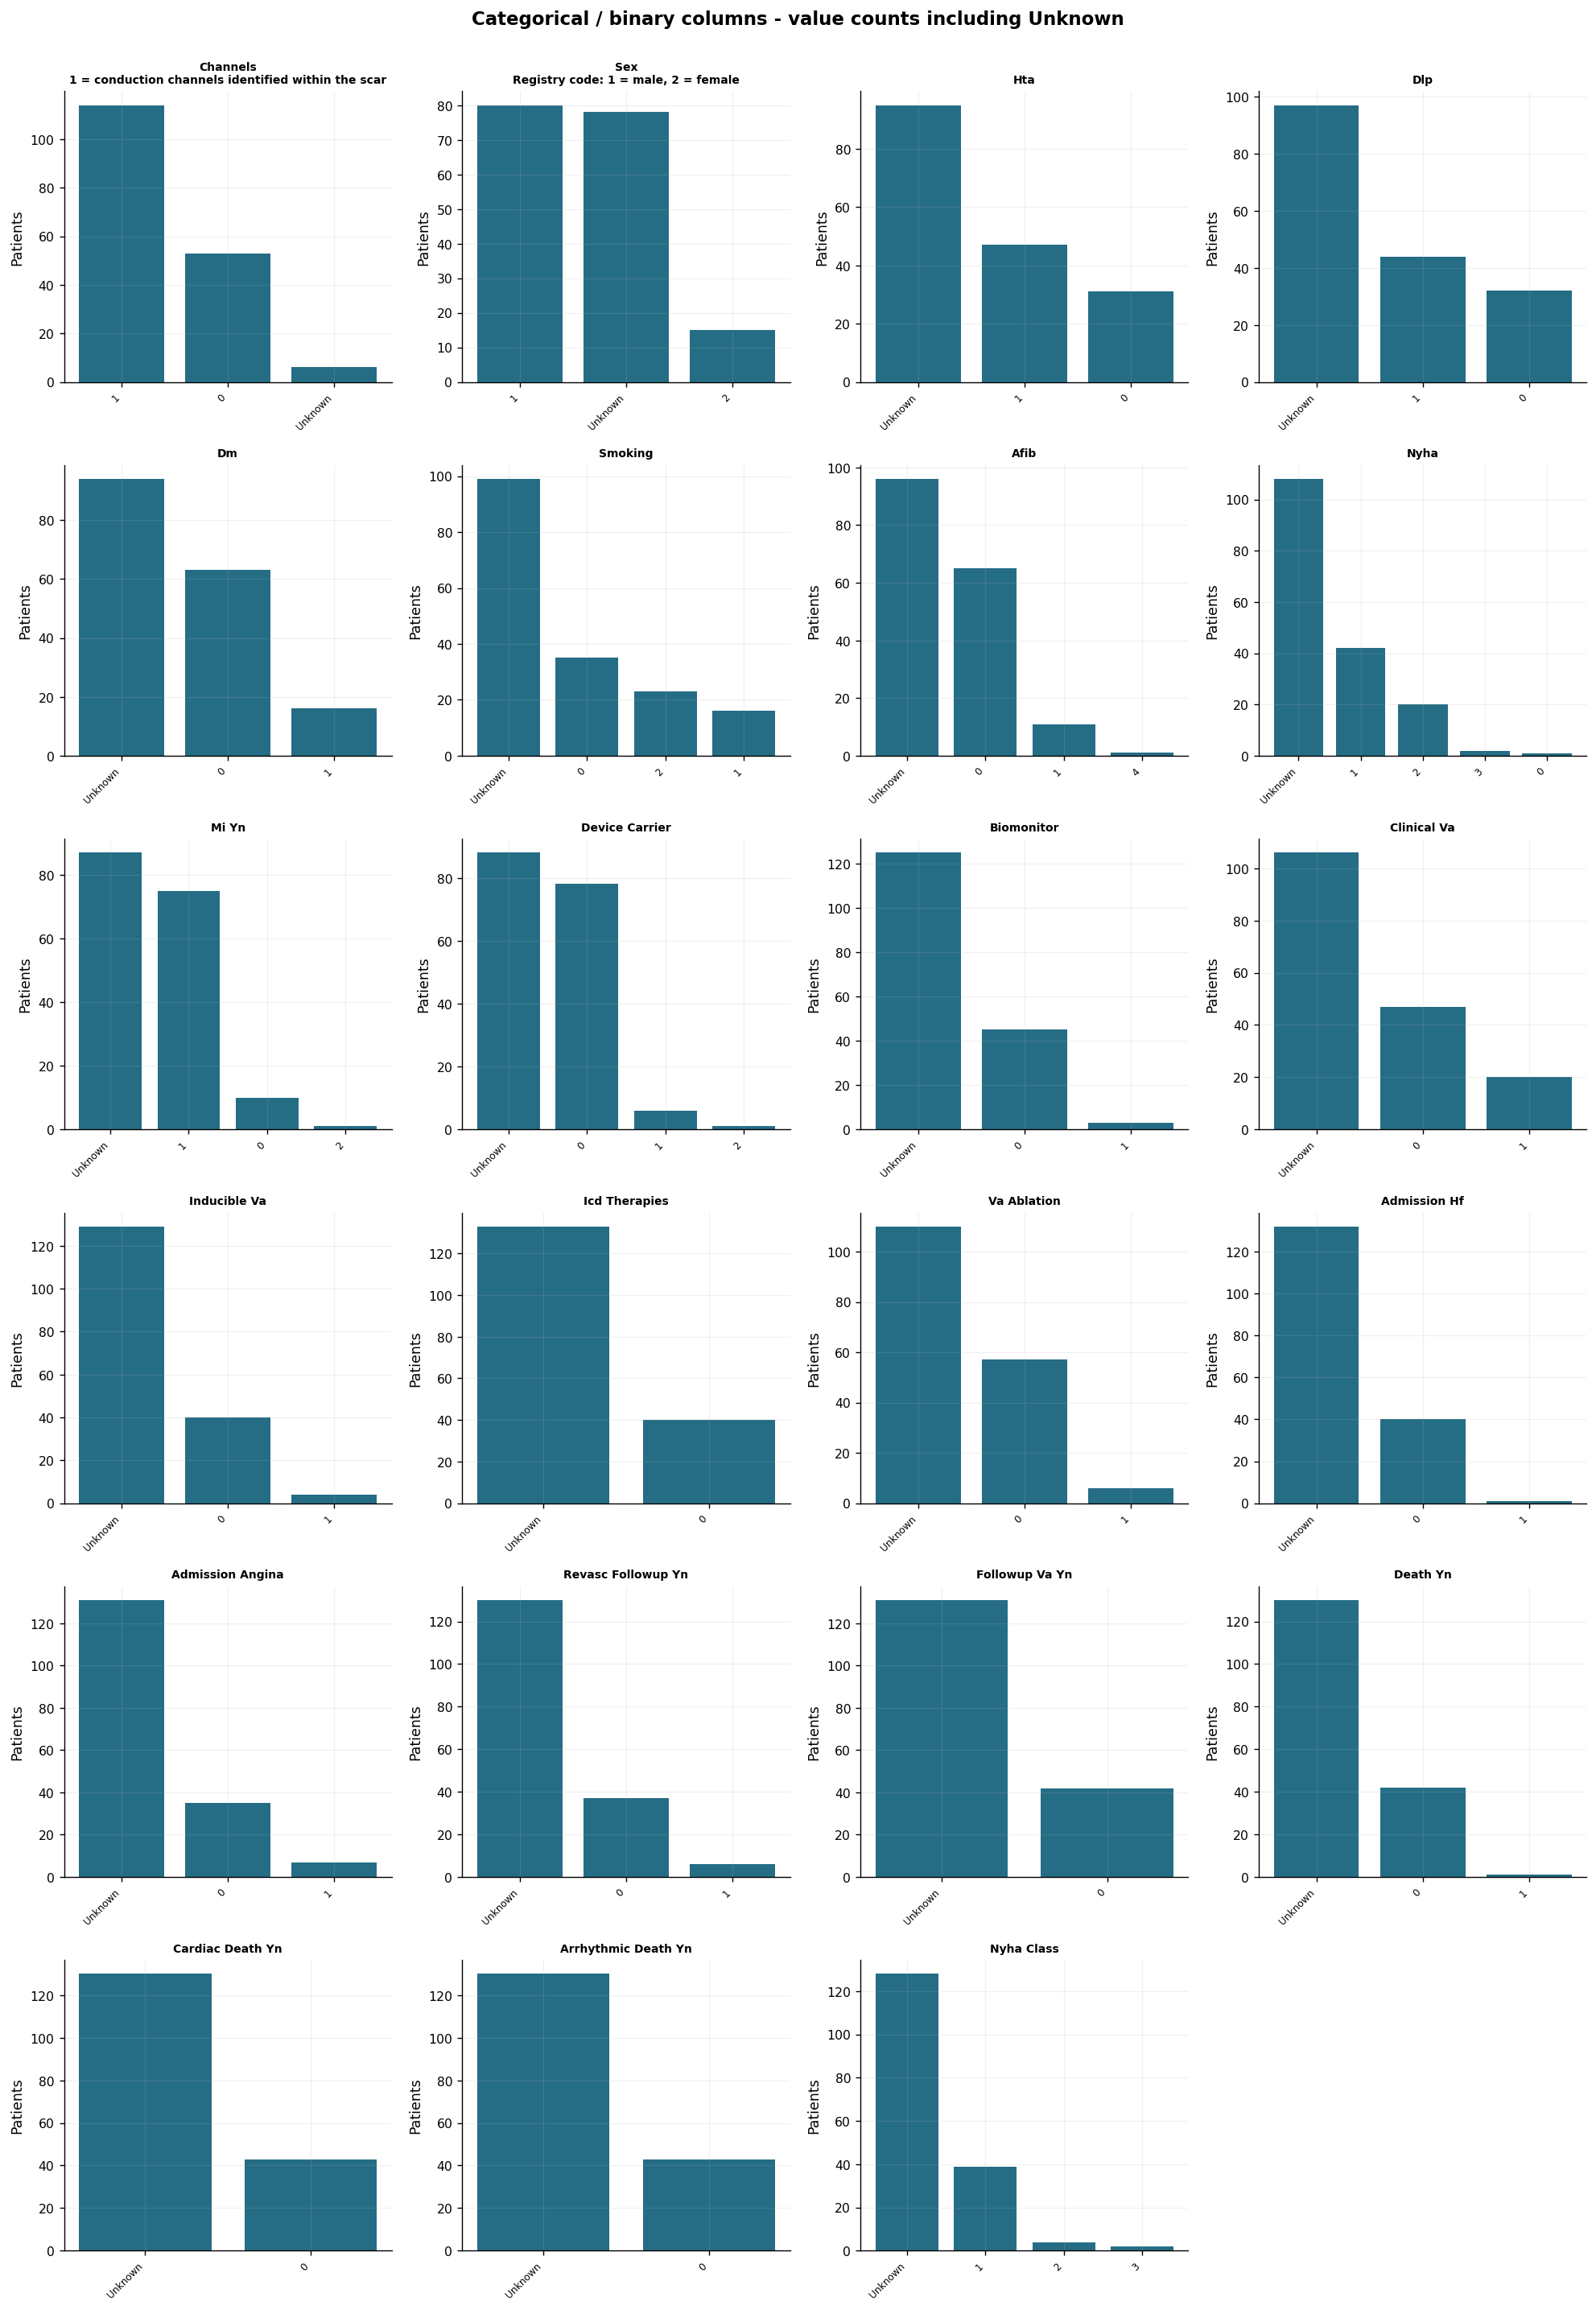

In [6]:
ignore = {
    c for c in df.columns
    if 'date' in c or c in ('patient_id', 'patient_id_norm', 'diagnosis', 'revasc_notes',
                             'other_notes', 'ablation_notes', 'va_notes',
                             'notes_misc', 'notes_followup_va')
}
cat_cols = [
    c for c in df.columns
    if c not in ignore
    and df[c].notna().sum() >= 3
    and (
        df[c].dtype == object
        or (pd.api.types.is_integer_dtype(df[c]) and df[c].nunique() <= 10)
    )
]

n_cols = 4
n_rows = ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.9 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    s = df[col].copy()
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        s = s.replace('', np.nan)
    vc = s.astype('string').fillna('Unknown').value_counts(dropna=False).head(10)
    axes[i].bar(range(len(vc)), vc.values, color=HIST_COLOR)
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels(vc.index, rotation=45, ha='right', fontsize=7)
    axes[i].set_title(variable_title(col), fontsize=8)
    axes[i].set_ylabel('Patients')

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Categorical / binary columns - value counts including Unknown', fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.savefig(RESULTS_DIR / '01c_cat_counts.png', bbox_inches='tight')
plt.show()


## 2 · Population characterization

One sub-section per variable group.
- Continuous variables with many unique values → **KDE density curve** with median marker
- Binary / low-cardinality / text variables → **horizontal bar chart** of value counts

Date columns are skipped (already visible in overview).

In [7]:
def plot_group(df, cols, title, save_name, n_cols=4):
    skip = {c for c in cols if 'date' in c}
    pcols = [c for c in cols if c in df.columns and c not in skip]
    if not pcols:
        print(f'No plottable columns for: {title}')
        return
    n_rows = ceil(len(pcols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.1 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for i, col in enumerate(pcols):
        ax = axes[i]
        raw = df[col]
        s = raw.dropna()
        is_num = pd.api.types.is_numeric_dtype(raw)
        low_card = raw.nunique(dropna=True) <= 8
        if is_num and not low_card:
            plot_numeric_distribution(ax, s)
            ax.set_xlabel(variable_label(col))
            apply_tfg_style(ax)
        else:
            labelled = s.map(lambda v: display_label(col, v))
            vc = labelled.astype('string').fillna('Unknown').value_counts().head(8).sort_values()
            bars = ax.barh(vc.index, vc.values, color=HIST_COLOR, alpha=0.88)
            for bar, value in zip(bars, vc.values):
                ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, str(int(value)), va='center', fontsize=9, color=TFG_COLORS['text'])
            ax.set_xlabel('Patients')
            apply_tfg_style(ax, xgrid=True)
        ax.set_title(variable_label(col), fontsize=10, pad=8)
    for ax in axes[len(pcols):]: ax.set_visible(False)
    plt.suptitle(title, fontweight='semibold', fontsize=13, color=TFG_COLORS['text'])
    plt.tight_layout(rect=(0, 0, 1, 0.96), h_pad=2.0, w_pad=1.4)
    plt.savefig(RESULTS_DIR / f'{save_name}.png', bbox_inches='tight')
    plt.show()

### 2a · Demographics

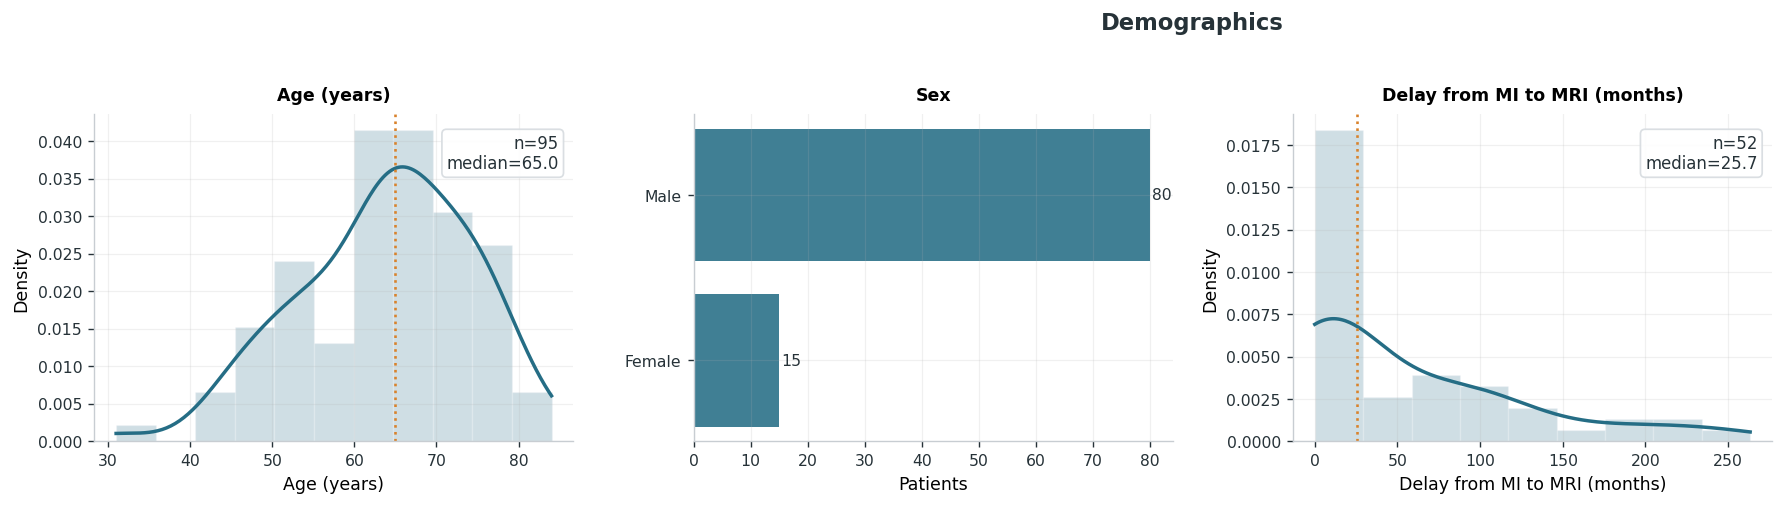

In [8]:
# Add MI-to-MRI delay in months as a derived column
if {'date_mi', 'date_mri'}.issubset(df.columns):
    df['mi_to_mri_months'] = (df['date_mri'] - df['date_mi']).dt.days / 30.44

demo_extra = ['age', 'sex', 'mi_to_mri_months']
plot_group(df, demo_extra, 'Demographics', '02a_demographics')

### 2a-1 - Age by sex

Age is shown as density distributions by sex to check whether the male and female groups have different age profiles.

,n,mean,std,median,min,max
sex_label,,,,,,
Female,15,61.13,9.95,62.0,45.0,75.0
Male,80,64.29,10.47,66.0,31.0,84.0
Unknown,0,NaN,NaN,NaN,NaN,NaN


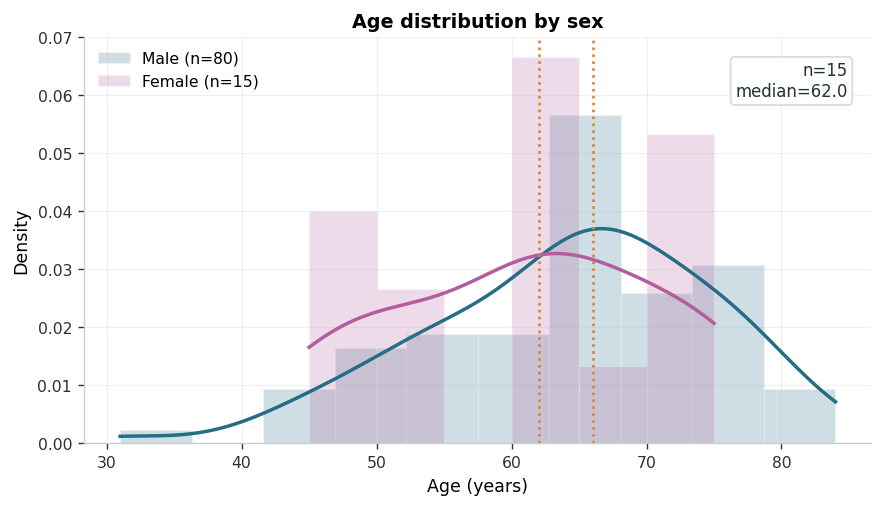

In [9]:
if {'age', 'sex'}.issubset(df.columns):
    age_by_sex = (df.assign(sex_label=df['sex'].map(SEX_LABELS).fillna('Unknown')).groupby('sex_label')['age'].agg(n='count', mean='mean', std='std', median='median', min='min', max='max').round(2).sort_index())
    display(age_by_sex)
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    sub = df[['age', 'sex']].dropna()
    for sex_code, sex_label in SEX_LABELS.items():
        vals = sub.loc[sub['sex'] == sex_code, 'age']
        if not vals.empty:
            plot_numeric_distribution(ax, vals, color=SEX_COLORS.get(sex_code, HIST_COLOR), label=f'{sex_label} (n={len(vals)})')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('Density'); ax.set_title('Age distribution by sex')
    ax.legend(loc='upper left', fontsize=9); apply_tfg_style(ax); plt.tight_layout()
    plt.savefig(RESULTS_DIR / '02a1_age_by_sex_distribution.png', bbox_inches='tight'); plt.show()

### 2b - MRI scar variables

Numeric scar variables are shown as distributions. For `enhancement_territory`, raw notes are converted into interpretable categories using a transparent keyword-scoring classifier. These categories should be clinically reviewed.

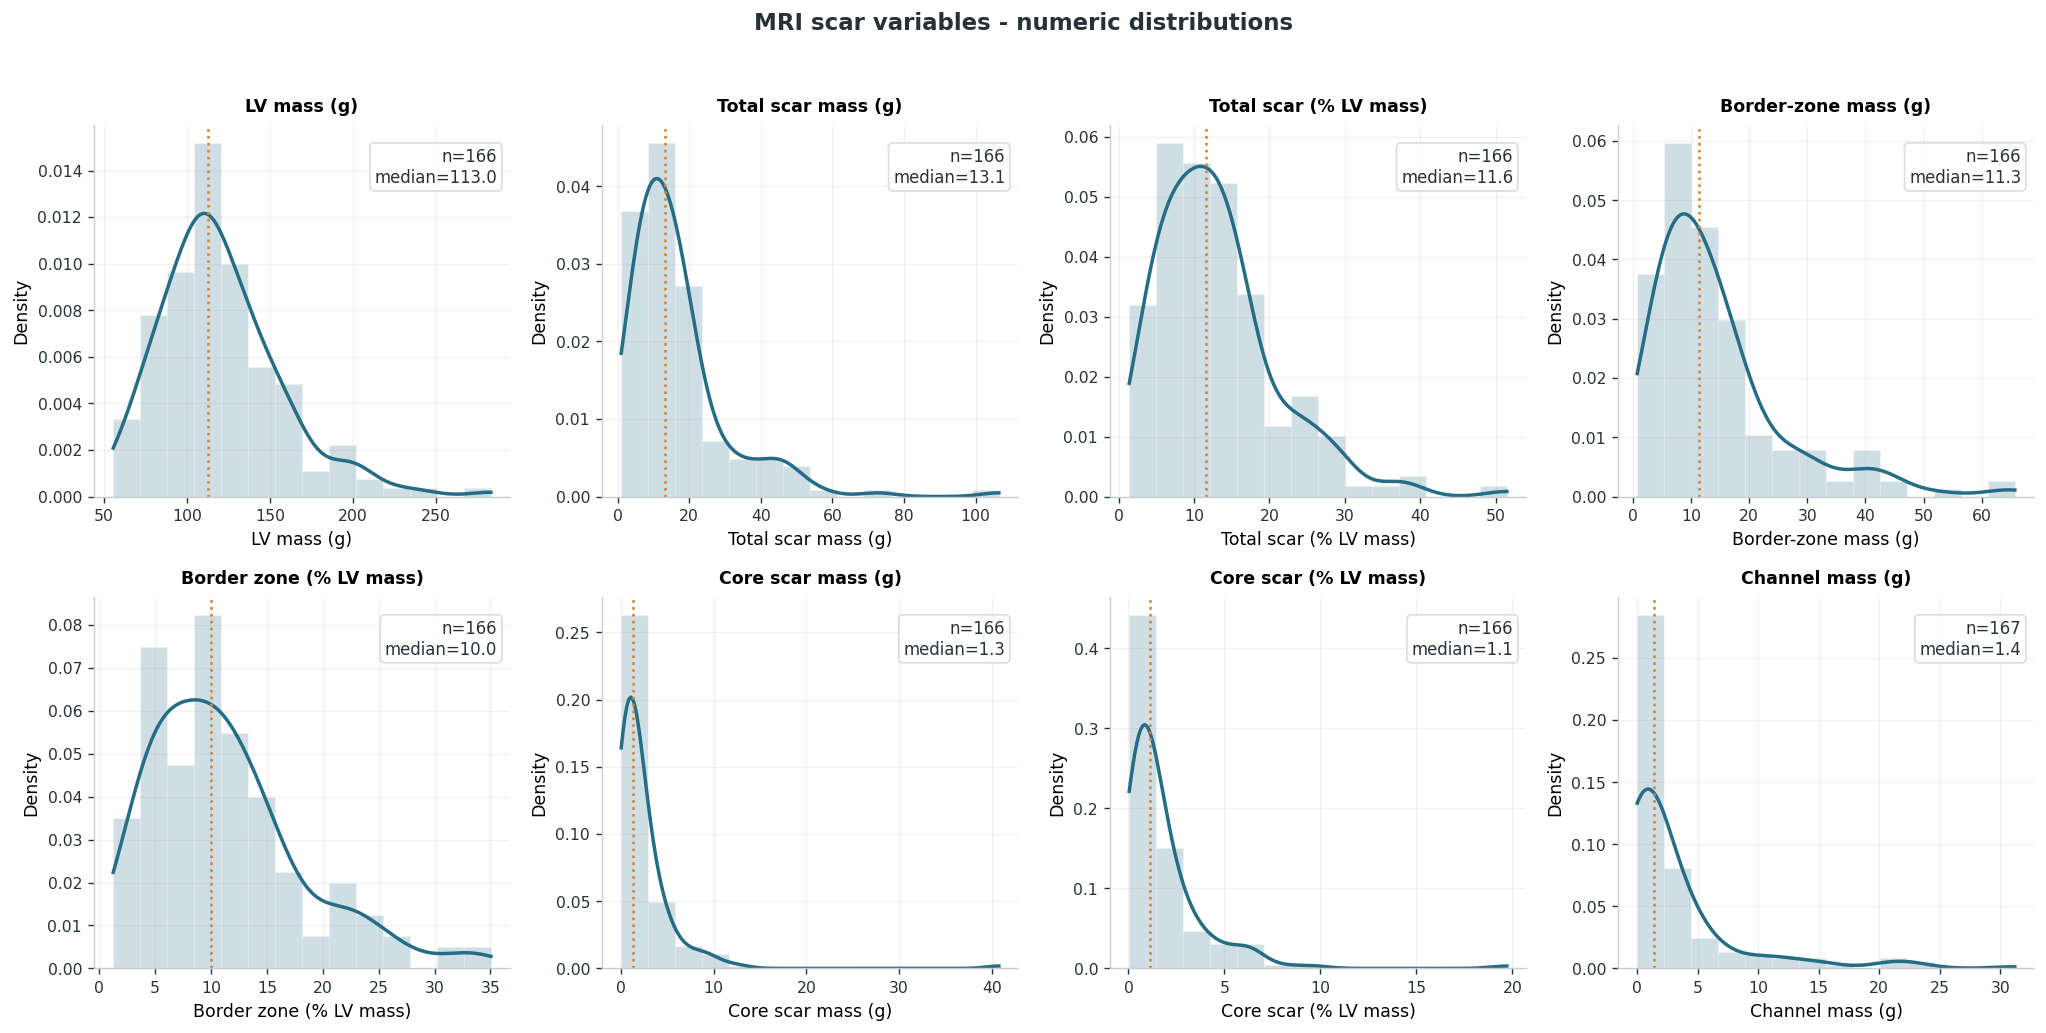

Examples of raw enhancement_territory values and interpreted categories:


,patient_id,enhancement_territory,enhancement_territory_ml_category,enhancement_territory_ml_confidence,enhancement_territory_ml_evidence
0,19040966,Anterior-anteroseptal medio y apical,Multi-territory / mixed,low,"ANTERIOR, ANTERO, ANTEROSEPTAL, SEPTAL, APICAL..."
1,19049863,Pared inferior e inferoseptal medio-basal,Multi-territory / mixed,medium,"SEPTAL, INFERIOR, INFERO, INFEROSEPTAL"
2,95010514,Subendo en segmentos inferolaterales medio-api...,Multi-territory / mixed,medium,"APICAL, INFERO, LATERAL, multi-marker"
3,2020684,Inferior medio transmural,RCA / inferior territory,medium,INFERIOR
4,14020661,Subendo inferolateral + AFECTACIÓN DEL PAPILAR PM,Multi-territory / mixed,medium,"INFERO, LATERAL, multi-marker"
5,6013083,Inferior-inferoseptal basal-medio,Multi-territory / mixed,medium,"SEPTAL, INFERIOR, INFERO, INFEROSEPTAL"
6,15037944,Anterolateral basal-media-apical,Multi-territory / mixed,medium,"ANTERO, APICAL, LATERAL"
7,NaN,Anterior-anterolateral,Multi-territory / mixed,medium,"ANTERIOR, ANTERO, LATERAL"
8,95006832,Subendo en cara lateral con signos de viabilid...,Multi-territory / mixed,medium,"DA, LATERAL, multi-marker"
9,19027131,Inferolateral,Multi-territory / mixed,medium,"INFERO, LATERAL"


Interpreted enhancement territory categories:


,enhancement_territory_ml_category,n
0,Missing,84
1,Multi-territory / mixed,71
2,RCA / inferior territory,9
3,LAD / anterior territory,7
4,Unclear / needs review,1
5,LCx / lateral territory,1


Cases to review with doctors:


,patient_id,enhancement_territory,enhancement_territory_ml_category,enhancement_territory_ml_confidence,enhancement_territory_ml_evidence
0,19040966,Anterior-anteroseptal medio y apical,Multi-territory / mixed,low,"ANTERIOR, ANTERO, ANTEROSEPTAL, SEPTAL, APICAL..."
1,19049863,Pared inferior e inferoseptal medio-basal,Multi-territory / mixed,medium,"SEPTAL, INFERIOR, INFERO, INFEROSEPTAL"
2,95010514,Subendo en segmentos inferolaterales medio-api...,Multi-territory / mixed,medium,"APICAL, INFERO, LATERAL, multi-marker"
3,14020661,Subendo inferolateral + AFECTACIÓN DEL PAPILAR PM,Multi-territory / mixed,medium,"INFERO, LATERAL, multi-marker"
4,6013083,Inferior-inferoseptal basal-medio,Multi-territory / mixed,medium,"SEPTAL, INFERIOR, INFERO, INFEROSEPTAL"
5,15037944,Anterolateral basal-media-apical,Multi-territory / mixed,medium,"ANTERO, APICAL, LATERAL"
6,NaN,Anterior-anterolateral,Multi-territory / mixed,medium,"ANTERIOR, ANTERO, LATERAL"
7,95006832,Subendo en cara lateral con signos de viabilid...,Multi-territory / mixed,medium,"DA, LATERAL, multi-marker"
8,19027131,Inferolateral,Multi-territory / mixed,medium,"INFERO, LATERAL"
9,4025011,Necrosis transmural anterior y anterolateral m...,Multi-territory / mixed,medium,"ANTERIOR, ANTERO, APICAL, LATERAL, multi-marker"


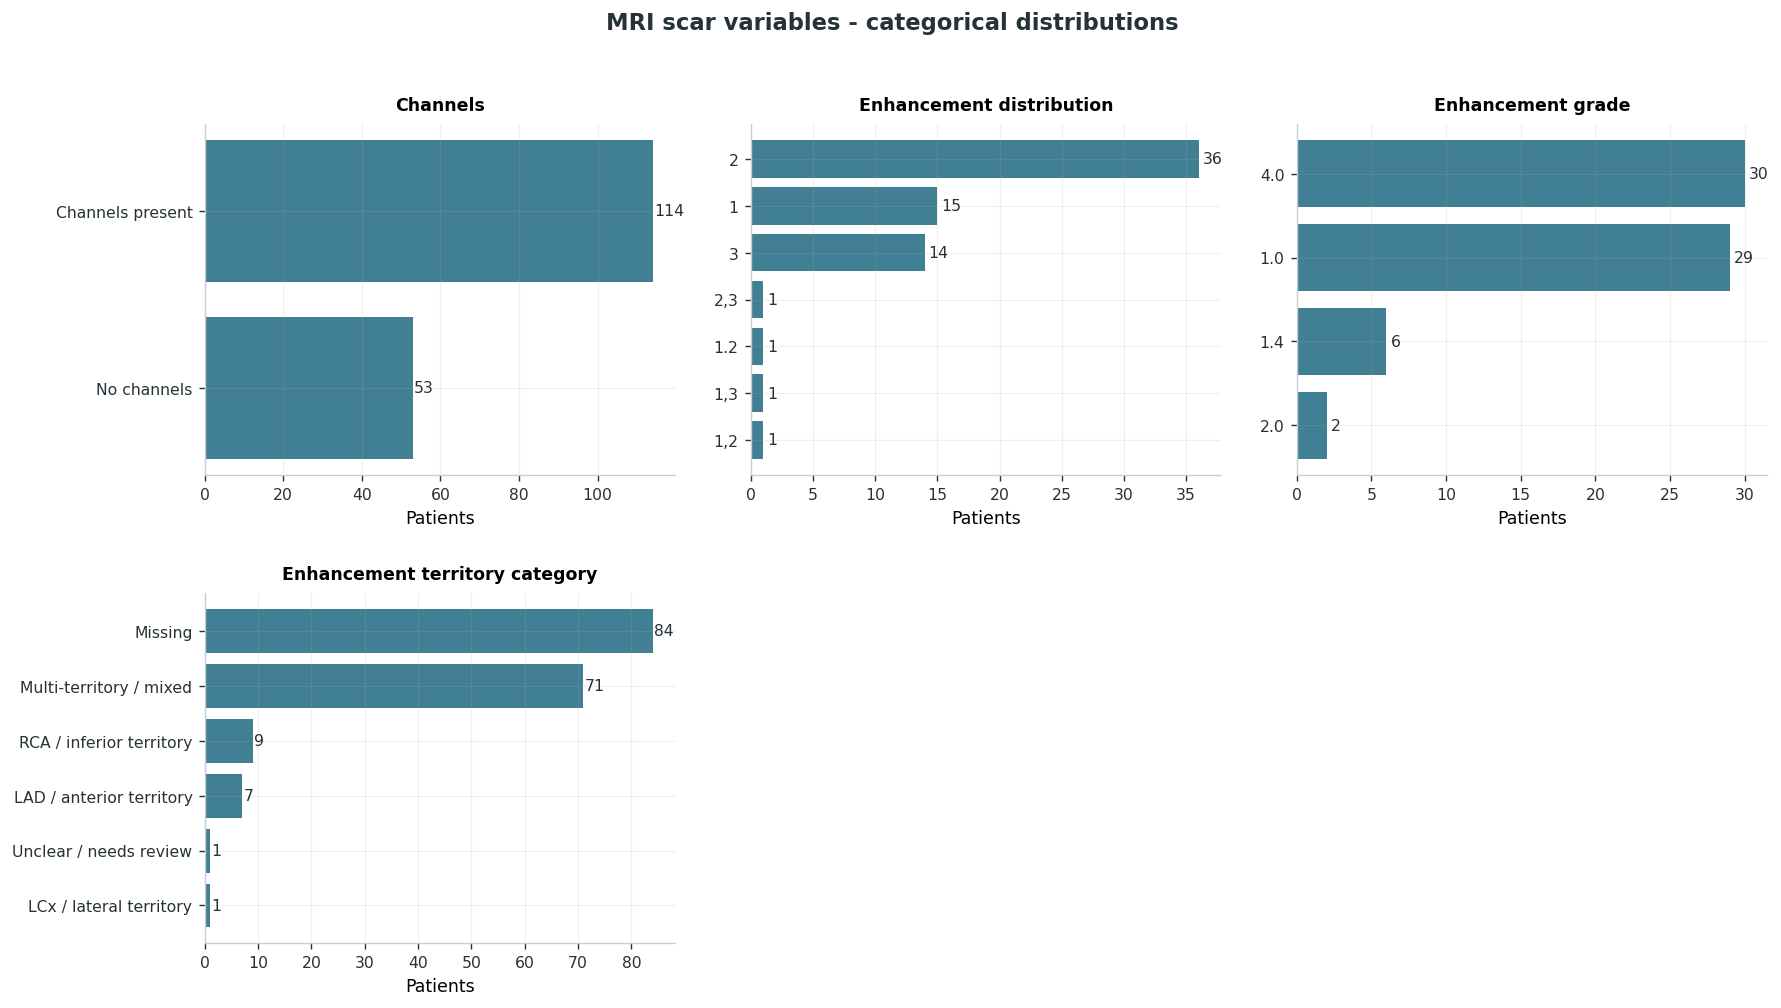

In [10]:
scar_cols = [c for c in COLUMN_GROUPS['scar_geometry'] if c in df.columns and 'date' not in c]
TERRITORY_KEYWORDS = {
    'LAD / anterior territory': ['LAD','DA','DESCENDENTE','ANTERIOR','ANTERO','ANTEROSEPTAL','SEPTAL','SEPTUM','APICAL','APEX','APICE'],
    'RCA / inferior territory': ['RCA','CD','CORONARIA DERECHA','DERECHA','INFERIOR','INFERO','INFEROSEPTAL','INFEROBASAL','POSTERIOR'],
    'LCx / lateral territory': ['LCX','CX','CIRCUNFLEJA','CIRCUMFLEX','LATERAL','POSTEROLATERAL'],
}
MULTI_TERRITORY_KEYWORDS = ['MULTI','MULTIVASO','BIVASO','TRIVASO','BIVAS','TRIVAS','+','/',',',';',' Y ',' AND ']
def classify_enhancement_territory_note(value):
    if pd.isna(value) or str(value).strip() == '':
        return pd.Series({'enhancement_territory_ml_category':'Missing','enhancement_territory_ml_confidence':'missing','enhancement_territory_ml_evidence':''})
    text = str(value).upper().strip(); scores={}; evidence={}
    for cat,kws in TERRITORY_KEYWORDS.items():
        hits=[kw for kw in kws if kw in text]; scores[cat]=len(hits); evidence[cat]=hits
    matched=[cat for cat,score in scores.items() if score>0]; has_multi=any(marker in text for marker in MULTI_TERRITORY_KEYWORDS)
    if len(matched)>=2 or (has_multi and len(matched)>=1):
        ev=[]
        for cat in matched: ev.extend(evidence[cat])
        if has_multi: ev.append('multi-marker')
        category='Multi-territory / mixed'; confidence='medium' if len(matched)>=2 else 'low'
    elif len(matched)==1:
        category=matched[0]; confidence='medium' if scores[category]==1 else 'high'; ev=evidence[category]
    else:
        category='Unclear / needs review'; confidence='low'; ev=[]
    return pd.Series({'enhancement_territory_ml_category':category,'enhancement_territory_ml_confidence':confidence,'enhancement_territory_ml_evidence':', '.join(dict.fromkeys(ev))})
if 'enhancement_territory' in df.columns:
    territory_ml = df['enhancement_territory'].apply(classify_enhancement_territory_note)
    df = pd.concat([df, territory_ml], axis=1)
    VARIABLE_INFO['enhancement_territory_ml_category'] = ('Enhancement territory category', 'Interpreted from raw note; requires clinical review')
scar_num = [c for c in scar_cols if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique(dropna=True) > 8]
scar_cat = [c for c in scar_cols if c not in scar_num]
if 'enhancement_territory_ml_category' in df.columns:
    scar_cat = [c for c in scar_cat if c != 'enhancement_territory'] + ['enhancement_territory_ml_category']
if scar_num:
    n_cols=4; n_rows=ceil(len(scar_num)/n_cols); fig, axes = plt.subplots(n_rows, n_cols, figsize=(16.5, 4.2*n_rows)); axes=np.atleast_1d(axes).flatten()
    for i,col in enumerate(scar_num):
        plot_numeric_distribution(axes[i], df[col]); axes[i].set_title(variable_label(col), fontsize=10, pad=8); axes[i].set_xlabel(variable_label(col)); apply_tfg_style(axes[i])
    for ax in axes[len(scar_num):]: ax.set_visible(False)
    plt.suptitle('MRI scar variables - numeric distributions', fontweight='semibold', color=TFG_COLORS['text']); plt.tight_layout(rect=(0,0,1,0.96)); plt.savefig(RESULTS_DIR / '02b_scar_numeric_distributions.png', bbox_inches='tight'); plt.show()
if 'enhancement_territory' in df.columns:
    print('Examples of raw enhancement_territory values and interpreted categories:')
    display(df.loc[df['enhancement_territory'].notna(), ['patient_id','enhancement_territory','enhancement_territory_ml_category','enhancement_territory_ml_confidence','enhancement_territory_ml_evidence']].drop_duplicates().head(30).reset_index(drop=True))
    print('Interpreted enhancement territory categories:')
    display(df['enhancement_territory_ml_category'].value_counts(dropna=False).rename_axis('enhancement_territory_ml_category').reset_index(name='n'))
    review_cases = df[df['enhancement_territory_ml_category'].isin(['Unclear / needs review','Multi-territory / mixed'])]
    if len(review_cases)>0:
        print('Cases to review with doctors:')
        display(review_cases[['patient_id','enhancement_territory','enhancement_territory_ml_category','enhancement_territory_ml_confidence','enhancement_territory_ml_evidence']].head(30).reset_index(drop=True))
if scar_cat:
    plot_group(df, scar_cat, 'MRI scar variables - categorical distributions', '02b_scar_categorical', n_cols=3)

### 2c · Risk factors

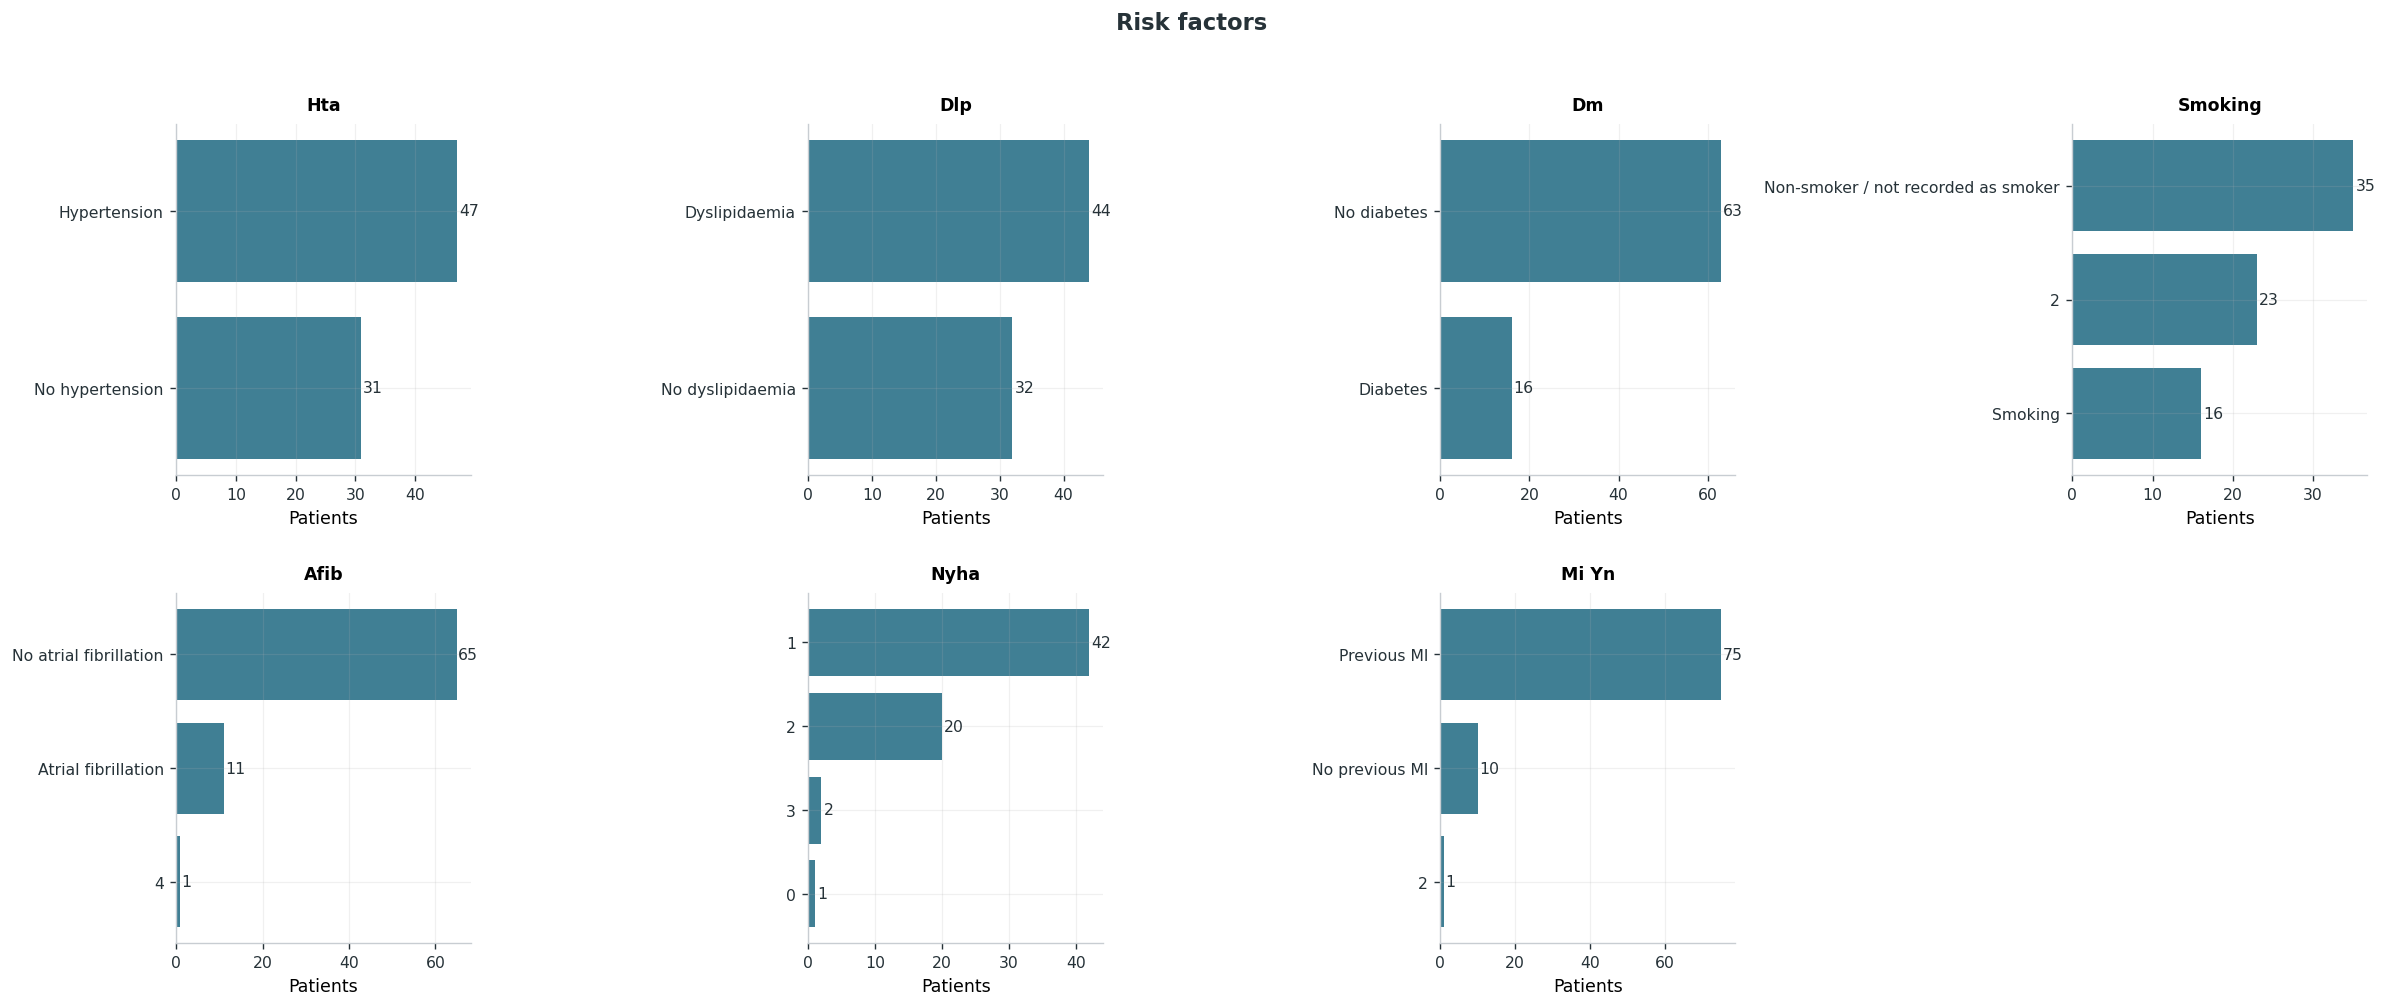

In [11]:
plot_group(df, COLUMN_GROUPS['risk_factors'], 'Risk factors', '02c_risk_factors')

### 2d · Infarctions & revascularization

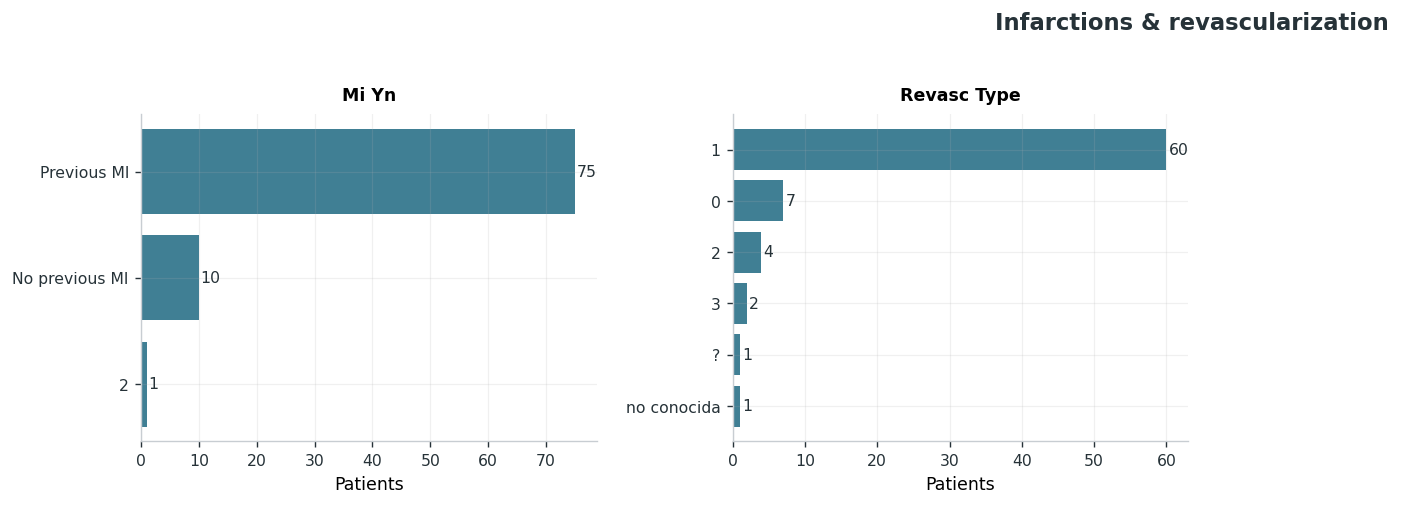

In [12]:
infarct_cols = [c for c in ['mi_yn', 'revasc_type', 'date_revasc'] if c in df.columns]
plot_group(df, infarct_cols, 'Infarctions & revascularization', '02d_infarct')

### 2e · Cardiac structure and function

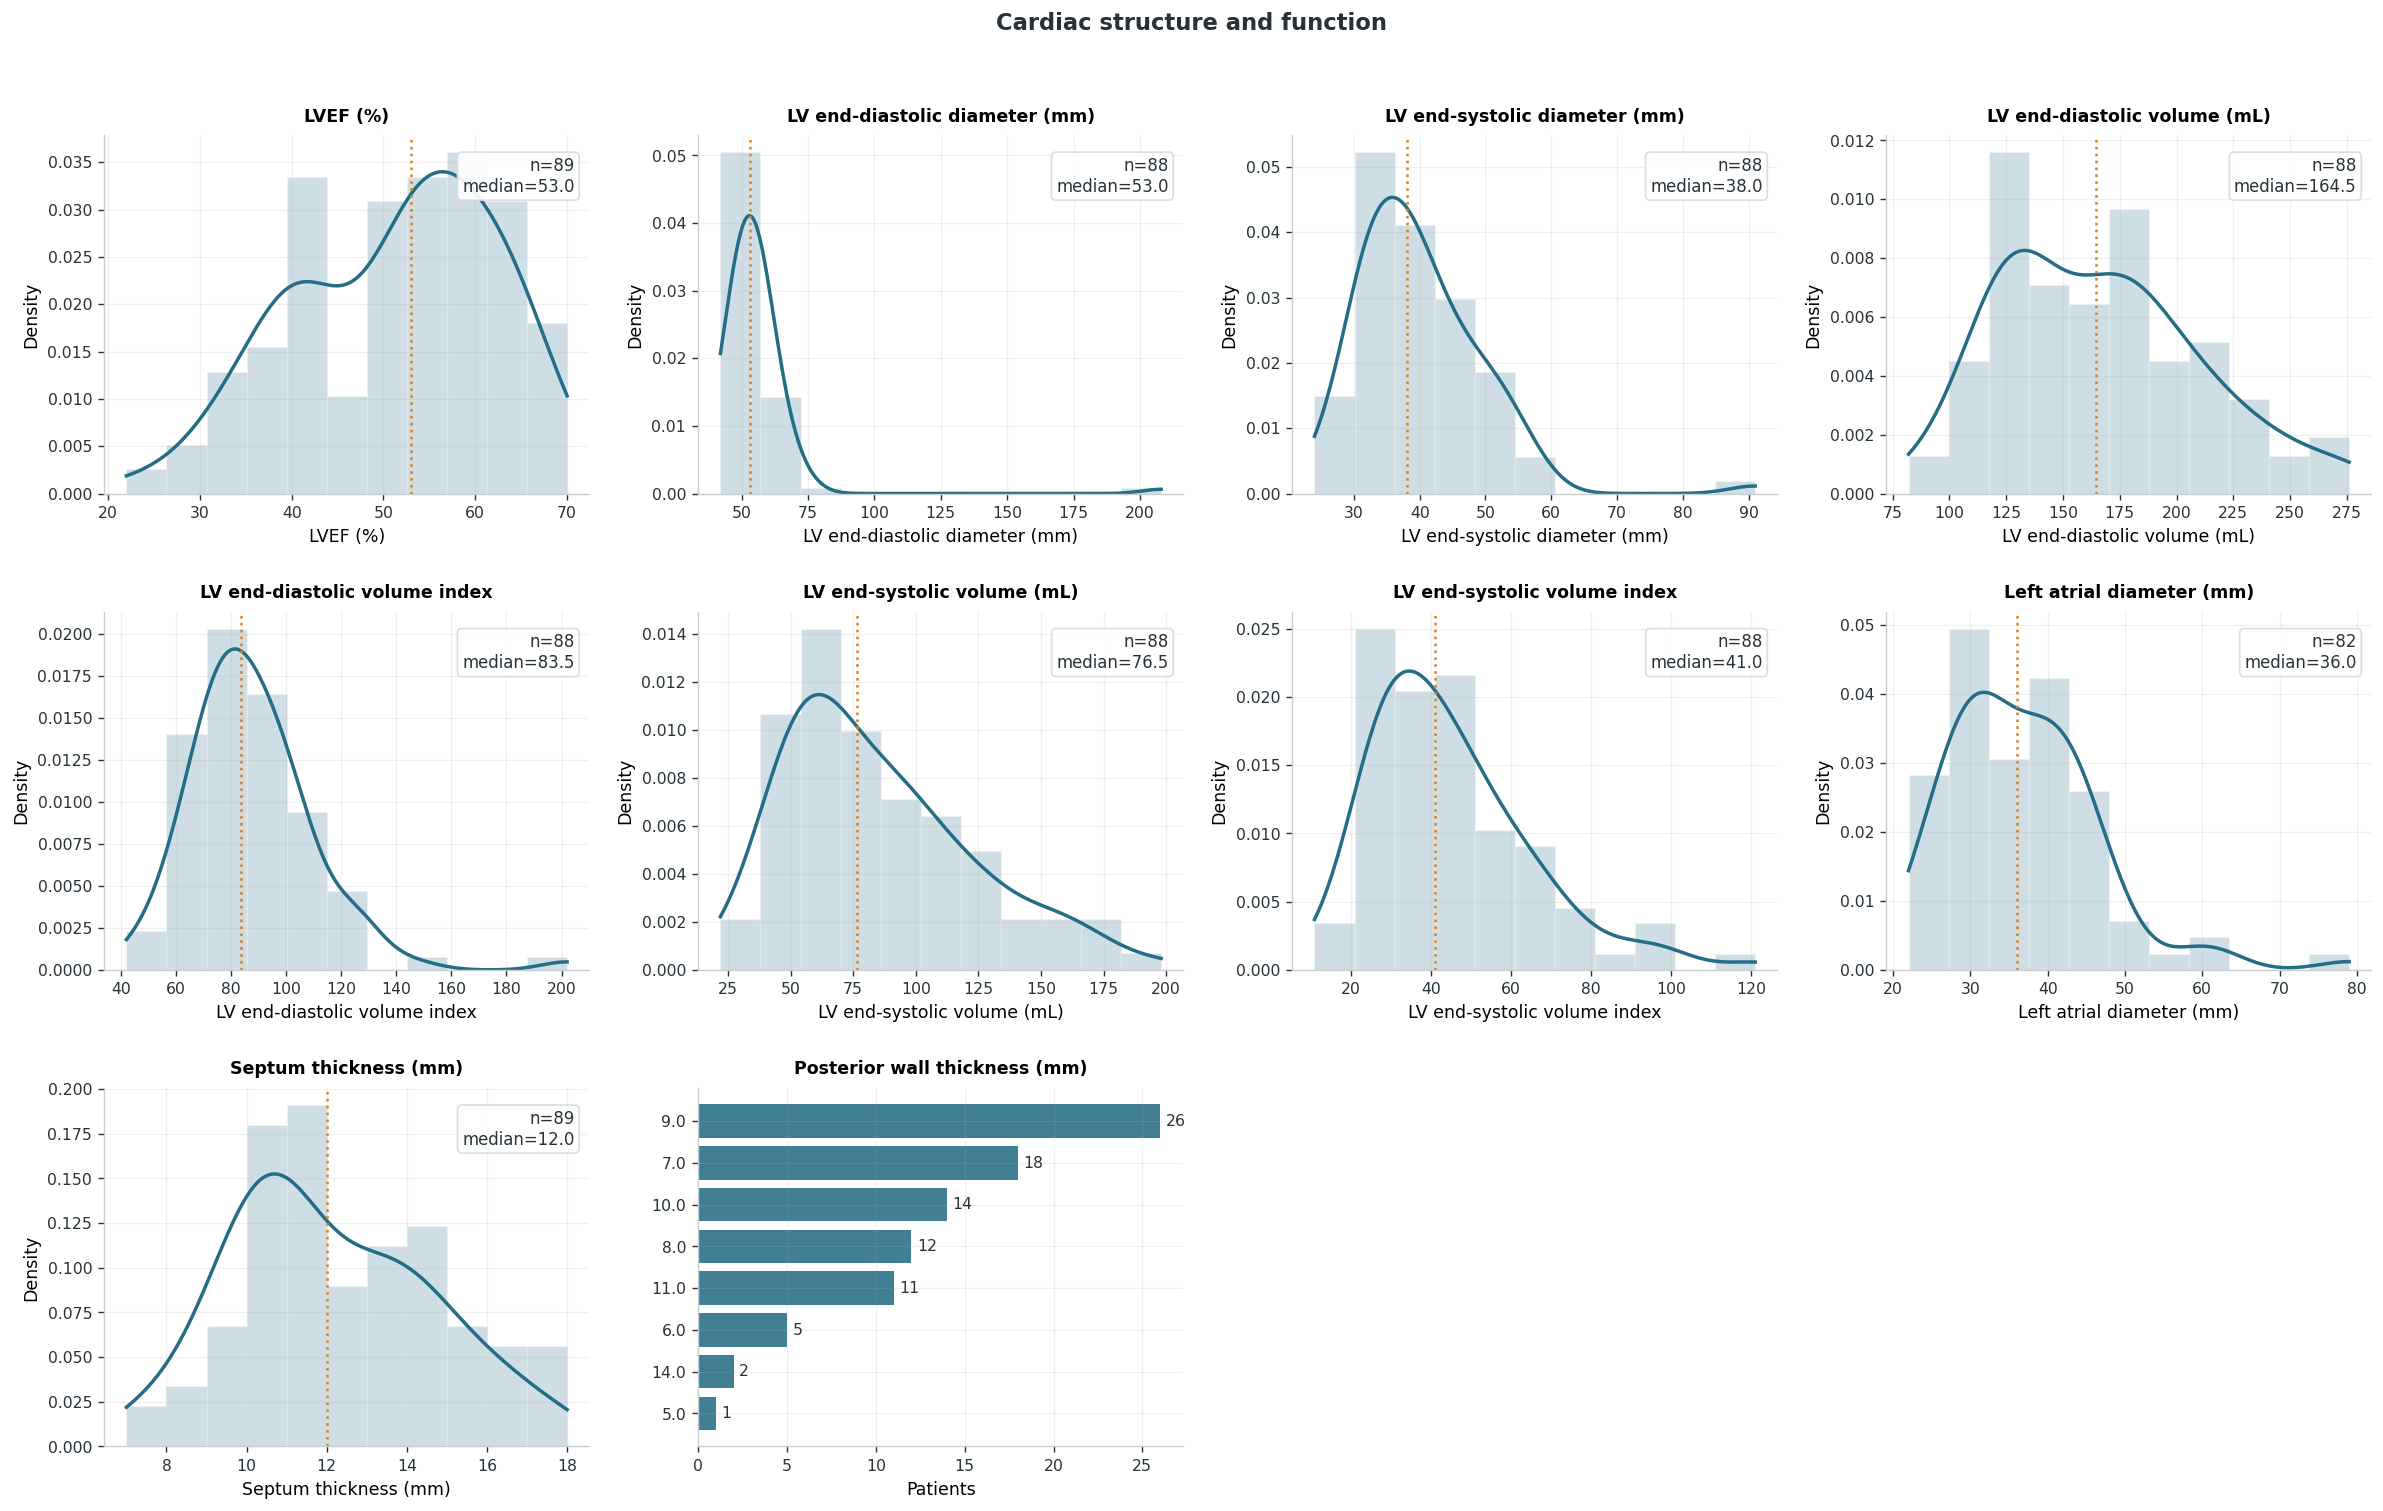

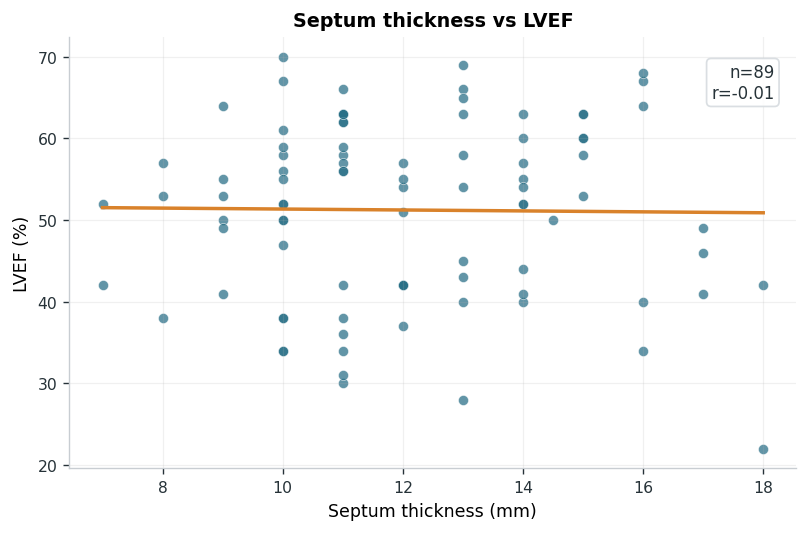

In [13]:
plot_group(df, COLUMN_GROUPS['echo'], 'Cardiac structure and function', '02e_echo')
if {'septum_mm', 'lvef_pct'}.issubset(df.columns):
    sub=df[['septum_mm','lvef_pct']].dropna()
    if len(sub)>=3:
        fig, ax=plt.subplots(figsize=(6.6,4.4)); x=pd.to_numeric(sub['septum_mm'], errors='coerce'); y=pd.to_numeric(sub['lvef_pct'], errors='coerce'); mask=x.notna() & y.notna(); x=x[mask]; y=y[mask]
        ax.scatter(x,y,color=HIST_COLOR,alpha=0.72,s=34,edgecolor='white',linewidth=0.4)
        if len(x)>=3 and float(x.std())>0:
            coeffs=np.polyfit(x,y,1); xs=np.linspace(float(x.min()),float(x.max()),100); ax.plot(xs, coeffs[0]*xs+coeffs[1], color=MEDIAN_COLOR, linewidth=2.0); r=float(pd.Series(x).corr(pd.Series(y))); add_panel_label(ax, f'n={len(x)}\nr={r:.2f}')
        ax.set_xlabel('Septum thickness (mm)'); ax.set_ylabel('LVEF (%)'); ax.set_title('Septum thickness vs LVEF'); apply_tfg_style(ax); plt.tight_layout(); plt.savefig(RESULTS_DIR / '02e_septum_vs_lvef.png', bbox_inches='tight'); plt.show()

### 2f · Devices

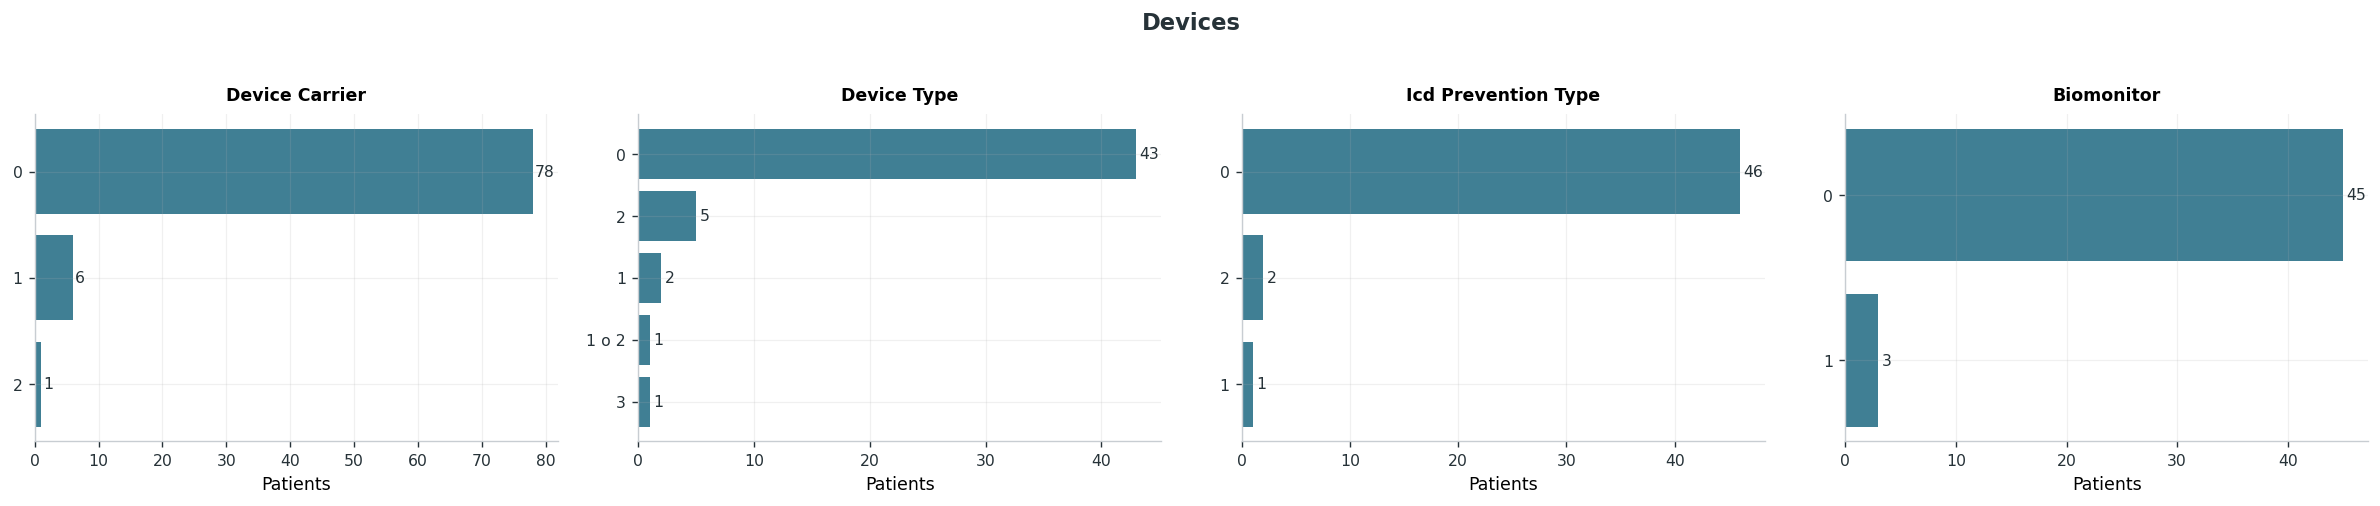

In [14]:
plot_group(df, COLUMN_GROUPS['devices'], 'Devices', '02f_devices')

### 2g · Ventricular arrhythmias

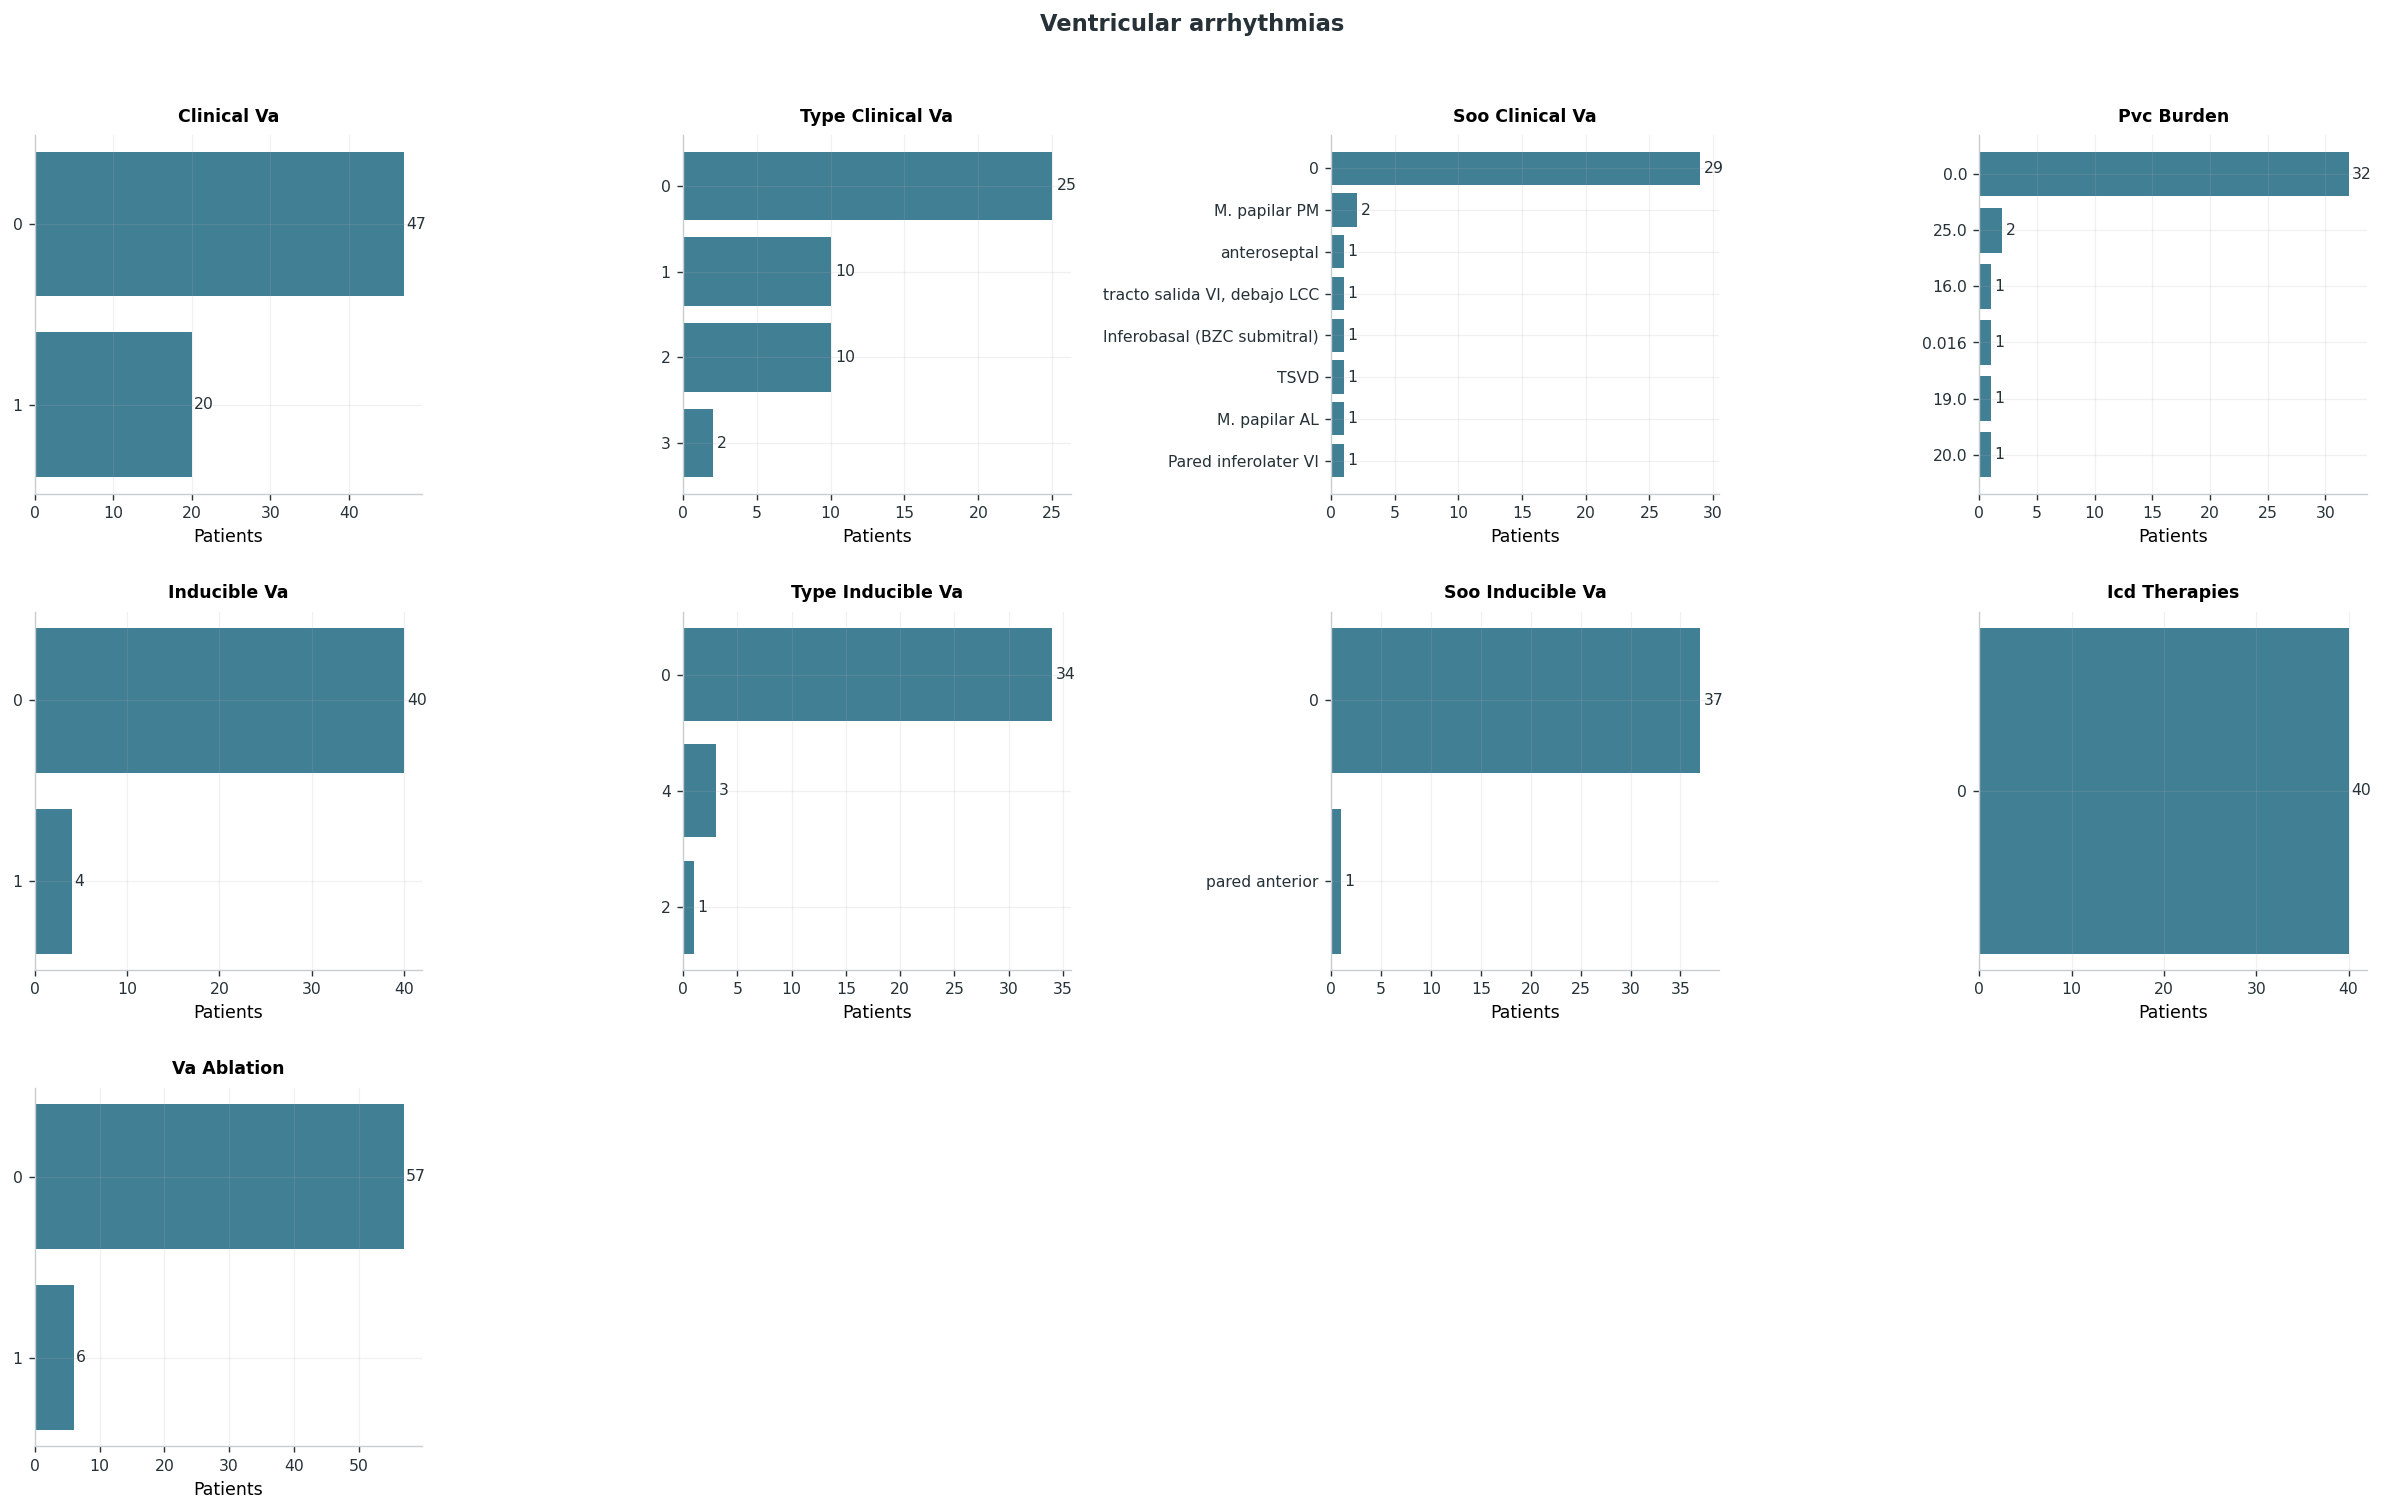

In [15]:
plot_group(df, COLUMN_GROUPS['arrhythmias'], 'Ventricular arrhythmias', '02g_arrhythmias')

### 2h · Follow-up outcomes

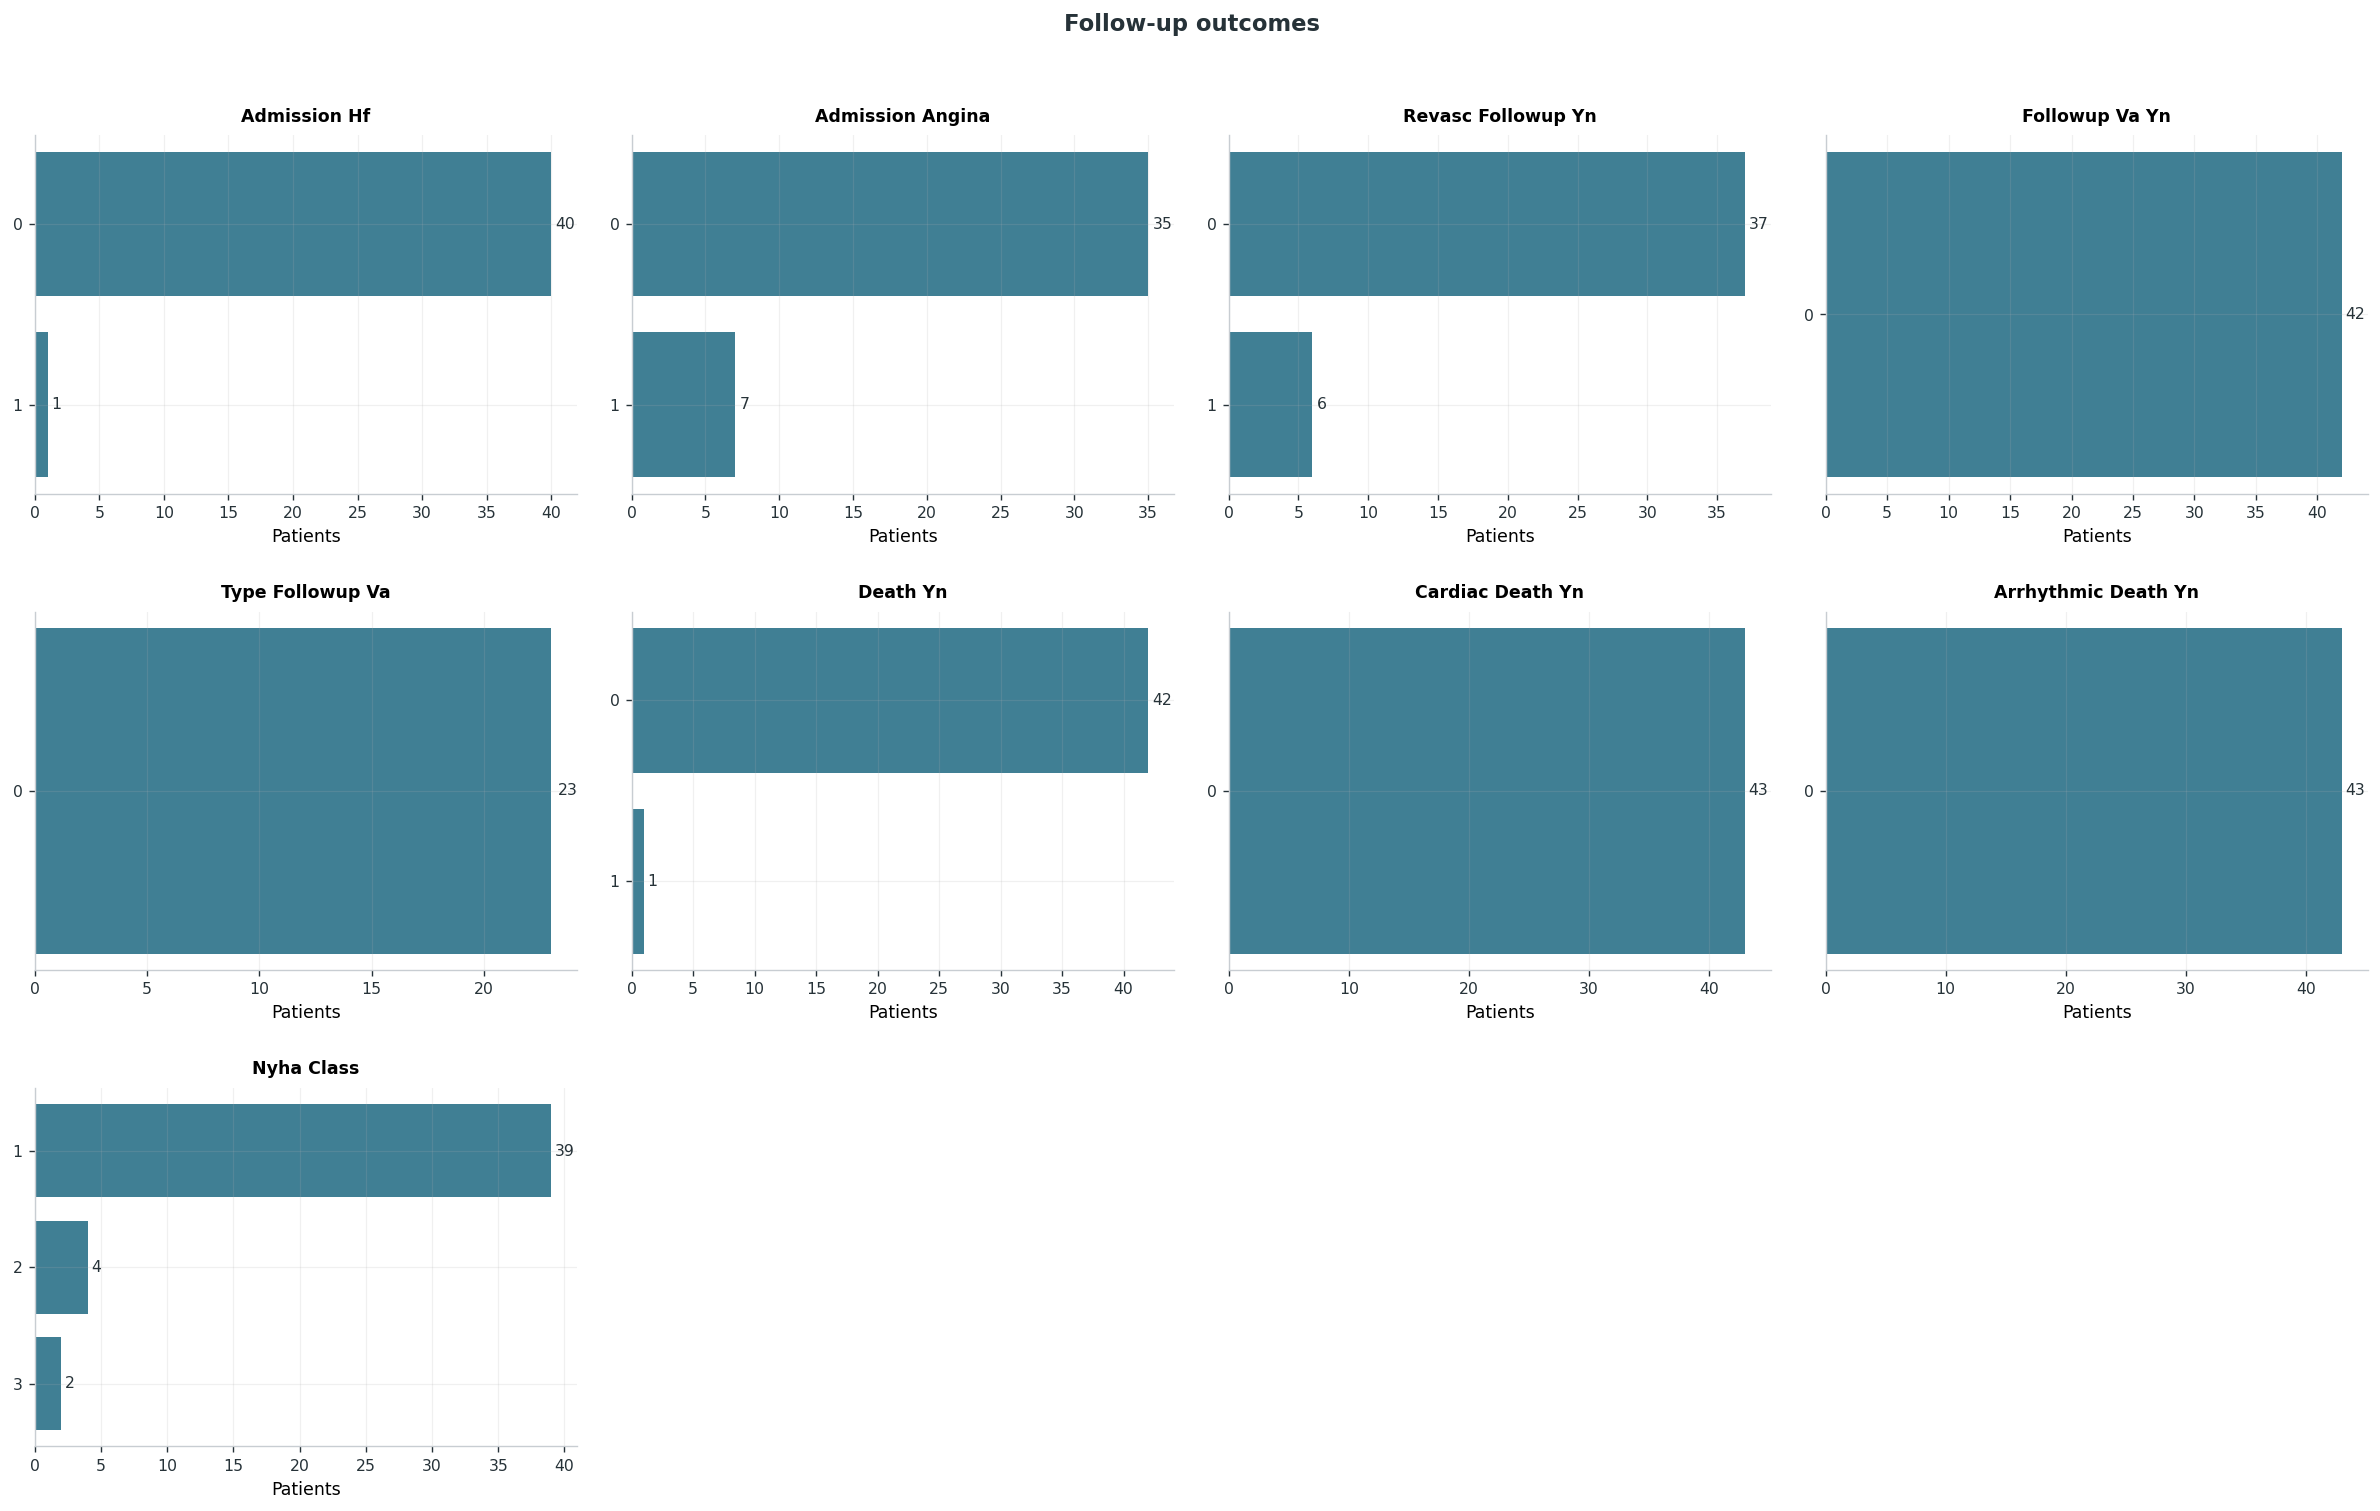

In [16]:
plot_group(df, COLUMN_GROUPS['followup'], 'Follow-up outcomes', '02h_followup')

## 3 · Risk factors

Stacked bar: **green** = factor present, **grey** = absent, **red hatched** = not recorded.
All bars add up to 100% of the total cohort.

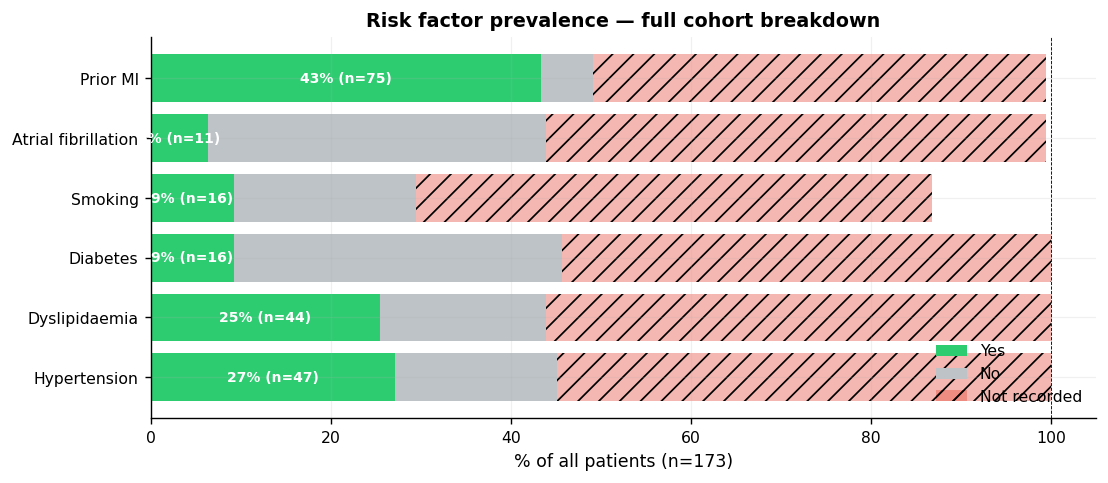

NYHA class distribution:
nyha
0         1
1        42
2        20
3         2
<NA>    108
Name: count, dtype: Int64


In [17]:
rf_cols   = [c for c in ['hta', 'dlp', 'dm', 'smoking', 'afib', 'mi_yn'] if c in df.columns]
rf_labels = {
    'hta': 'Hypertension', 'dlp': 'Dyslipidaemia', 'dm': 'Diabetes',
    'smoking': 'Smoking', 'afib': 'Atrial fibrillation', 'mi_yn': 'Prior MI',
}
n_total = len(df)

yes_pct  = [(df[c] == 1).sum() / n_total * 100 for c in rf_cols]
no_pct   = [(df[c] == 0).sum() / n_total * 100 for c in rf_cols]
miss_pct = [df[c].isna().sum()  / n_total * 100 for c in rf_cols]
labels   = [rf_labels.get(c, c) for c in rf_cols]

fig, ax = plt.subplots(figsize=(9, 4))
y = list(range(len(rf_cols)))
ax.barh(y, yes_pct, color='#2ecc71', label='Yes')
ax.barh(y, no_pct,  left=yes_pct,    color='#bdc3c7', label='No')
ax.barh(y, miss_pct,
        left=[a + b for a, b in zip(yes_pct, no_pct)],
        color='#e74c3c', alpha=0.4, hatch='//', label='Not recorded')

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('% of all patients (n=173)')
ax.set_xlim(0, 105)
ax.axvline(100, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Risk factor prevalence — full cohort breakdown')
ax.legend(loc='lower right', fontsize=9)

for i, (pct, c) in enumerate(zip(yes_pct, rf_cols)):
    n = int((df[c] == 1).sum())
    if pct > 5:
        ax.text(pct / 2, i, f'{pct:.0f}% (n={n})',
                ha='center', va='center', fontsize=8,
                color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_risk_factors.png', bbox_inches='tight')
plt.show()

if 'nyha' in df.columns:
    print('NYHA class distribution:')
    print(df['nyha'].value_counts(dropna=False).sort_index())

## 4 - Scar geometry (detailed)

### Variable glossary

`pct` means **percentage**. In this notebook, scar variables ending in `_pct` are percentages of LV mass, not raw grams.
For example, `bz_core_pct` = total scar burden normalized by LV mass, while `bz_core_g` = total scar burden in grams.

| Variable | Meaning |
|---|---|
| **lv_mass_g** | Total left ventricular myocardial mass (grams). |
| **bz_core_g / bz_core_pct** | Total scar = border zone + core (g / % of LV mass). |
| **core_g / core_pct** | Core scar - dense, fully infarcted, electrically silent tissue. |
| **bz_g / bz_pct** | Border zone - transitional tissue between healthy muscle and core. Primary substrate for VT re-entry. |
| **channels** | Conduction channels inside the scar (1 = present, 0 = absent). Surviving myocyte corridors that form VT circuit isthmuses. |
| **channel_mass_g** | Total mass of identified channels. |
| **enhancement_territory** | Coronary territory of the scar (LAD, RCA, LCx). |
| **enhancement_distribution** | Wall-layer distribution. Numeric codes - clinician clarification still needed. |
| **enhancement_grade** | Enhancement extent / intensity score. Higher values should mean more extensive enhancement, but the exact clinical coding should be confirmed. |
| **mri_type** | Acquisition type or quality flag for the MRI. |



### 4a · Continuous scar metrics

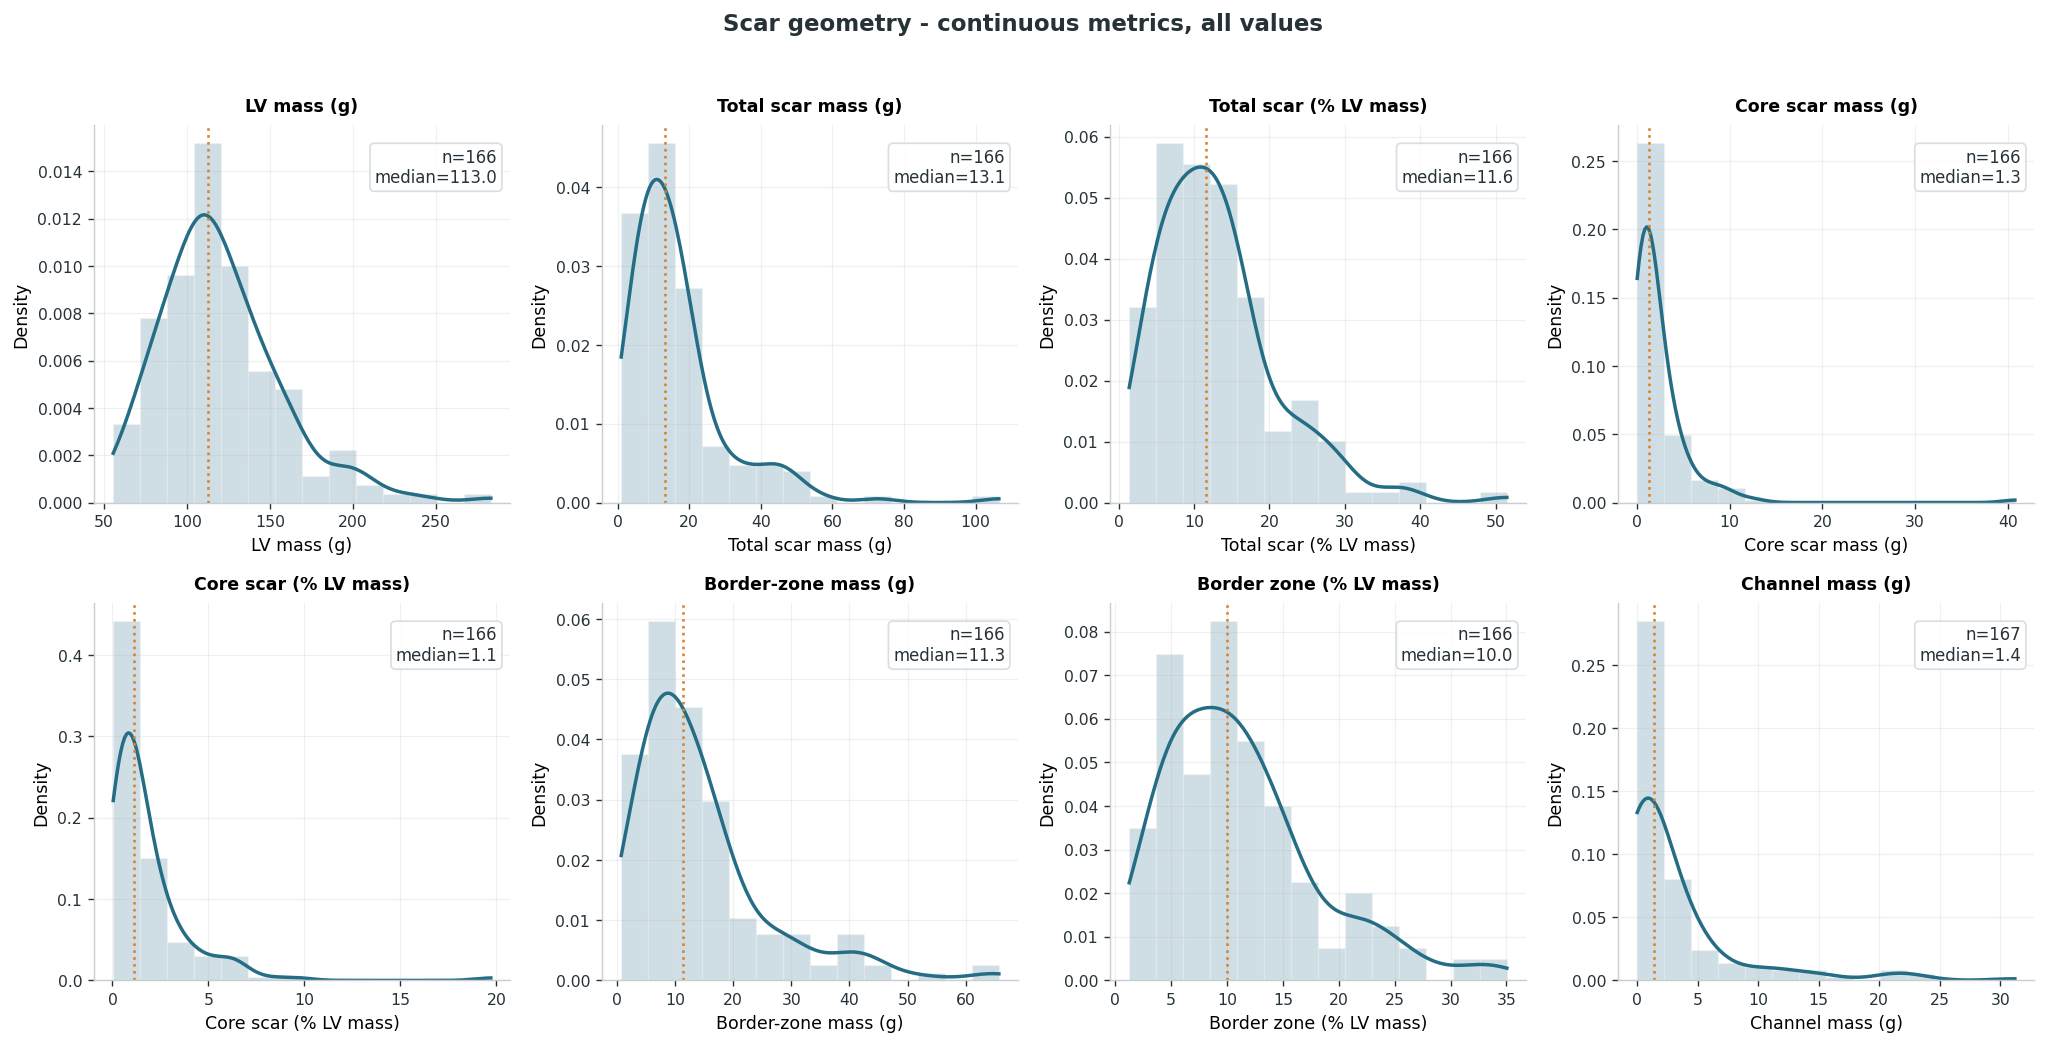

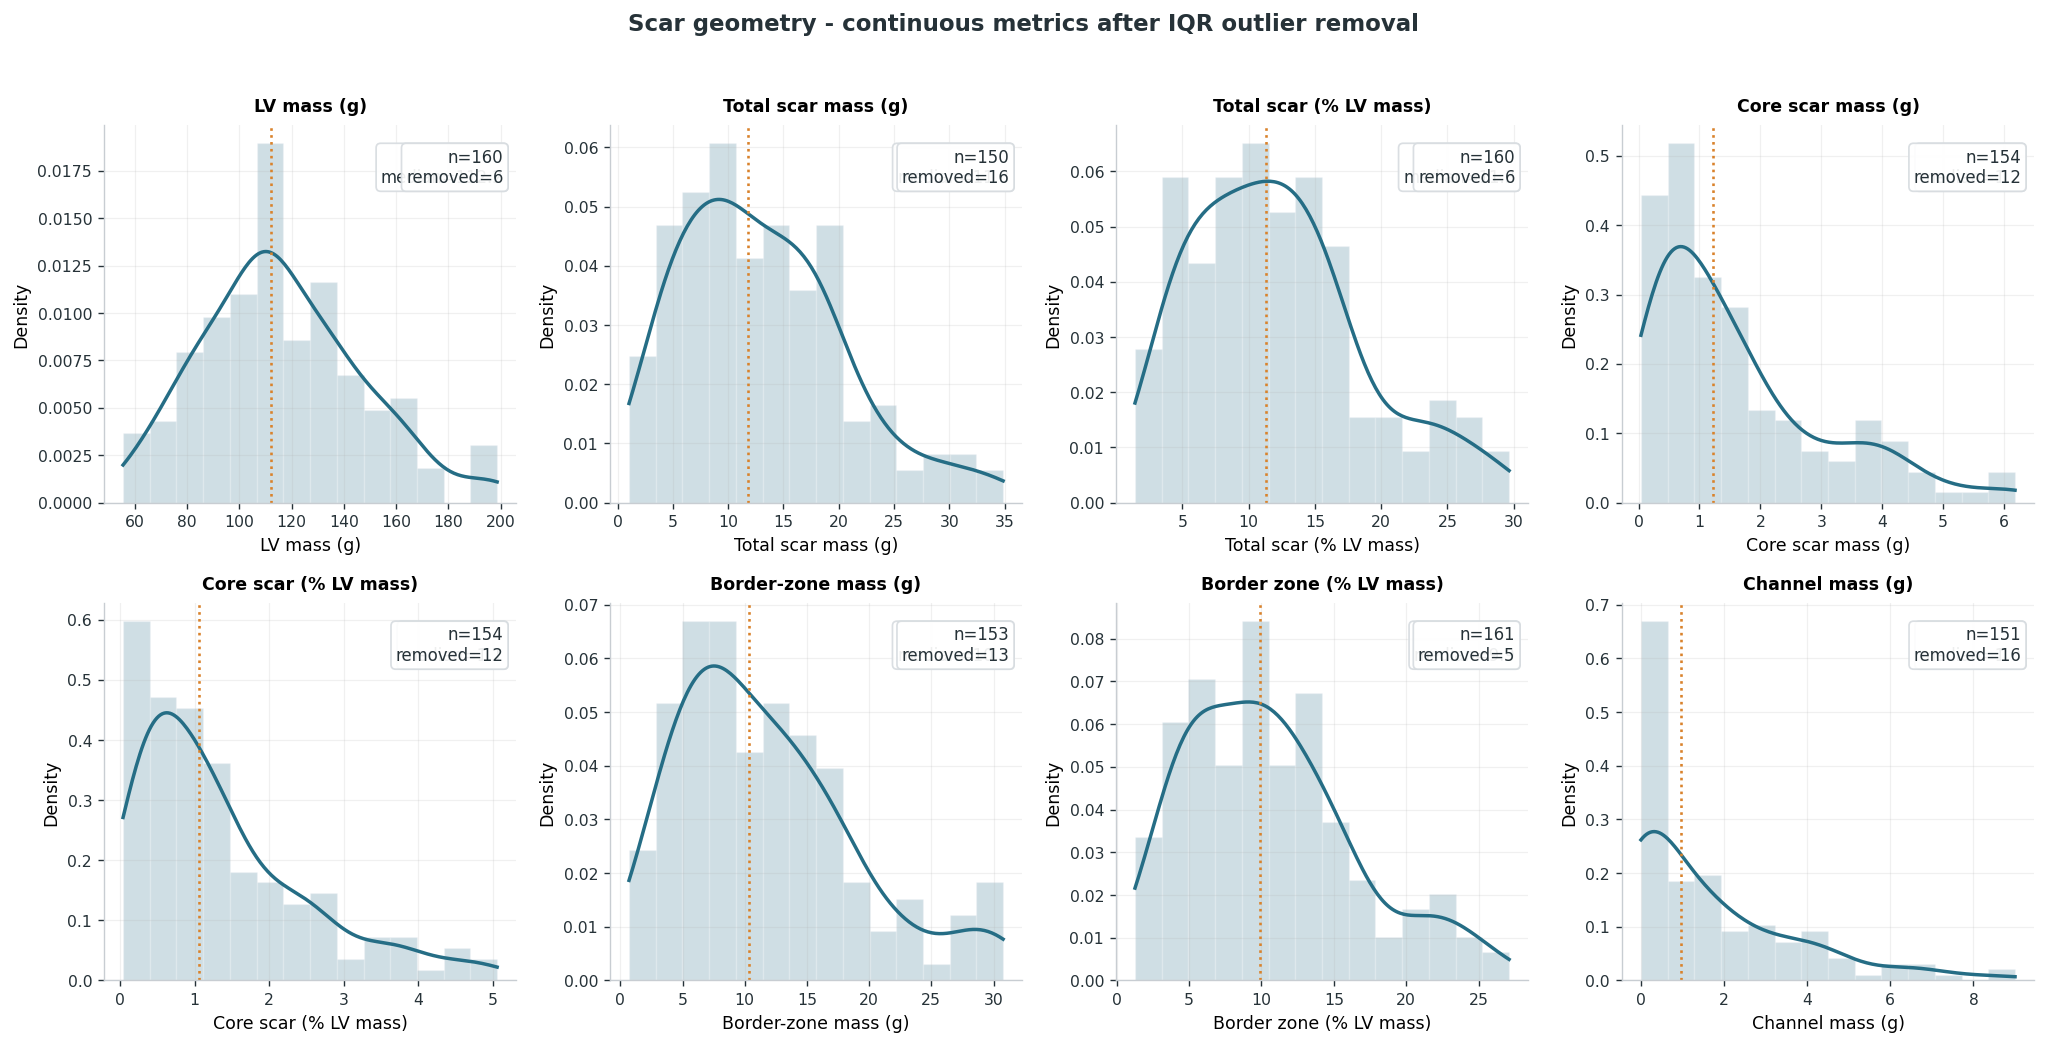

IQR outlier-removal report:


,variable,n_original,n_after_iqr_filter,n_removed
0,lv_mass_g,166,160,6
1,bz_core_g,166,150,16
2,bz_core_pct,166,160,6
3,core_g,166,154,12
4,core_pct,166,154,12
5,bz_g,166,153,13
6,bz_pct,166,161,5
7,channel_mass_g,167,151,16


Descriptive statistics, all values:


,lv_mass_g,bz_core_g,bz_core_pct,core_g,core_pct,bz_g,bz_pct,channel_mass_g
count,166.00,166.00,166.00,166.00,166.00,166.00,166.00,167.00
mean,120.24,16.64,13.05,2.33,1.81,14.33,11.25,3.10
std,36.82,14.14,8.02,3.80,2.24,11.66,6.85,5.14
min,55.54,1.04,1.42,0.04,0.04,0.70,1.26,0.00
25%,95.20,7.93,7.49,0.55,0.47,6.58,5.93,0.00
50%,112.96,13.14,11.55,1.30,1.10,11.30,9.98,1.40
75%,137.32,19.33,16.40,2.81,2.32,17.68,14.48,3.68
max,283.25,106.50,51.50,40.76,19.71,65.73,35.04,31.20


In [18]:
scar_num = [c for c in ['lv_mass_g', 'bz_core_g', 'bz_core_pct', 'core_g', 'core_pct', 'bz_g', 'bz_pct', 'channel_mass_g'] if c in df.columns]
def plot_scar_metric_distributions(data_frame, columns, title, save_name, remove_outliers=False):
    n_cols=4; n_rows=ceil(len(columns)/n_cols); fig, axes=plt.subplots(n_rows, n_cols, figsize=(16.5, 4.25*n_rows)); axes=np.atleast_1d(axes).flatten(); rows=[]
    for i,col in enumerate(columns):
        vals_all=pd.to_numeric(data_frame[col], errors='coerce').dropna(); vals=iqr_filter(vals_all) if remove_outliers else vals_all; removed=len(vals_all)-len(vals)
        plot_numeric_distribution(axes[i], vals); axes[i].set_title(variable_label(col), fontsize=10, pad=8); axes[i].set_xlabel(variable_label(col)); apply_tfg_style(axes[i])
        if remove_outliers: add_panel_label(axes[i], f'n={len(vals)}\nremoved={removed}')
        rows.append({'variable':col,'n_original':len(vals_all),'n_after_iqr_filter':len(vals),'n_removed':removed})
    for ax in axes[len(columns):]: ax.set_visible(False)
    plt.suptitle(title, fontweight='semibold', color=TFG_COLORS['text']); plt.tight_layout(rect=(0,0,1,0.96)); plt.savefig(RESULTS_DIR / f'{save_name}.png', bbox_inches='tight'); plt.show(); return pd.DataFrame(rows)
plot_scar_metric_distributions(df, scar_num, 'Scar geometry - continuous metrics, all values', '04a_scar_continuous_all_values')
outlier_report = plot_scar_metric_distributions(df, scar_num, 'Scar geometry - continuous metrics after IQR outlier removal', '04b_scar_continuous_iqr_filtered', remove_outliers=True)
print('IQR outlier-removal report:'); display(outlier_report)
print('Descriptive statistics, all values:'); display(df[scar_num].describe().round(2))

## 5 - Correlation matrix: numeric variables

Pearson r is computed for numeric columns with at least 20 non-null values. Direct gram-versus-percent scar comparisons are excluded before plotting because they mostly compare the same scar component expressed in two different units.

Excluded from correlation matrix to avoid gram-vs-percent duplication:
['bz_core_pct', 'bz_pct', 'core_pct']


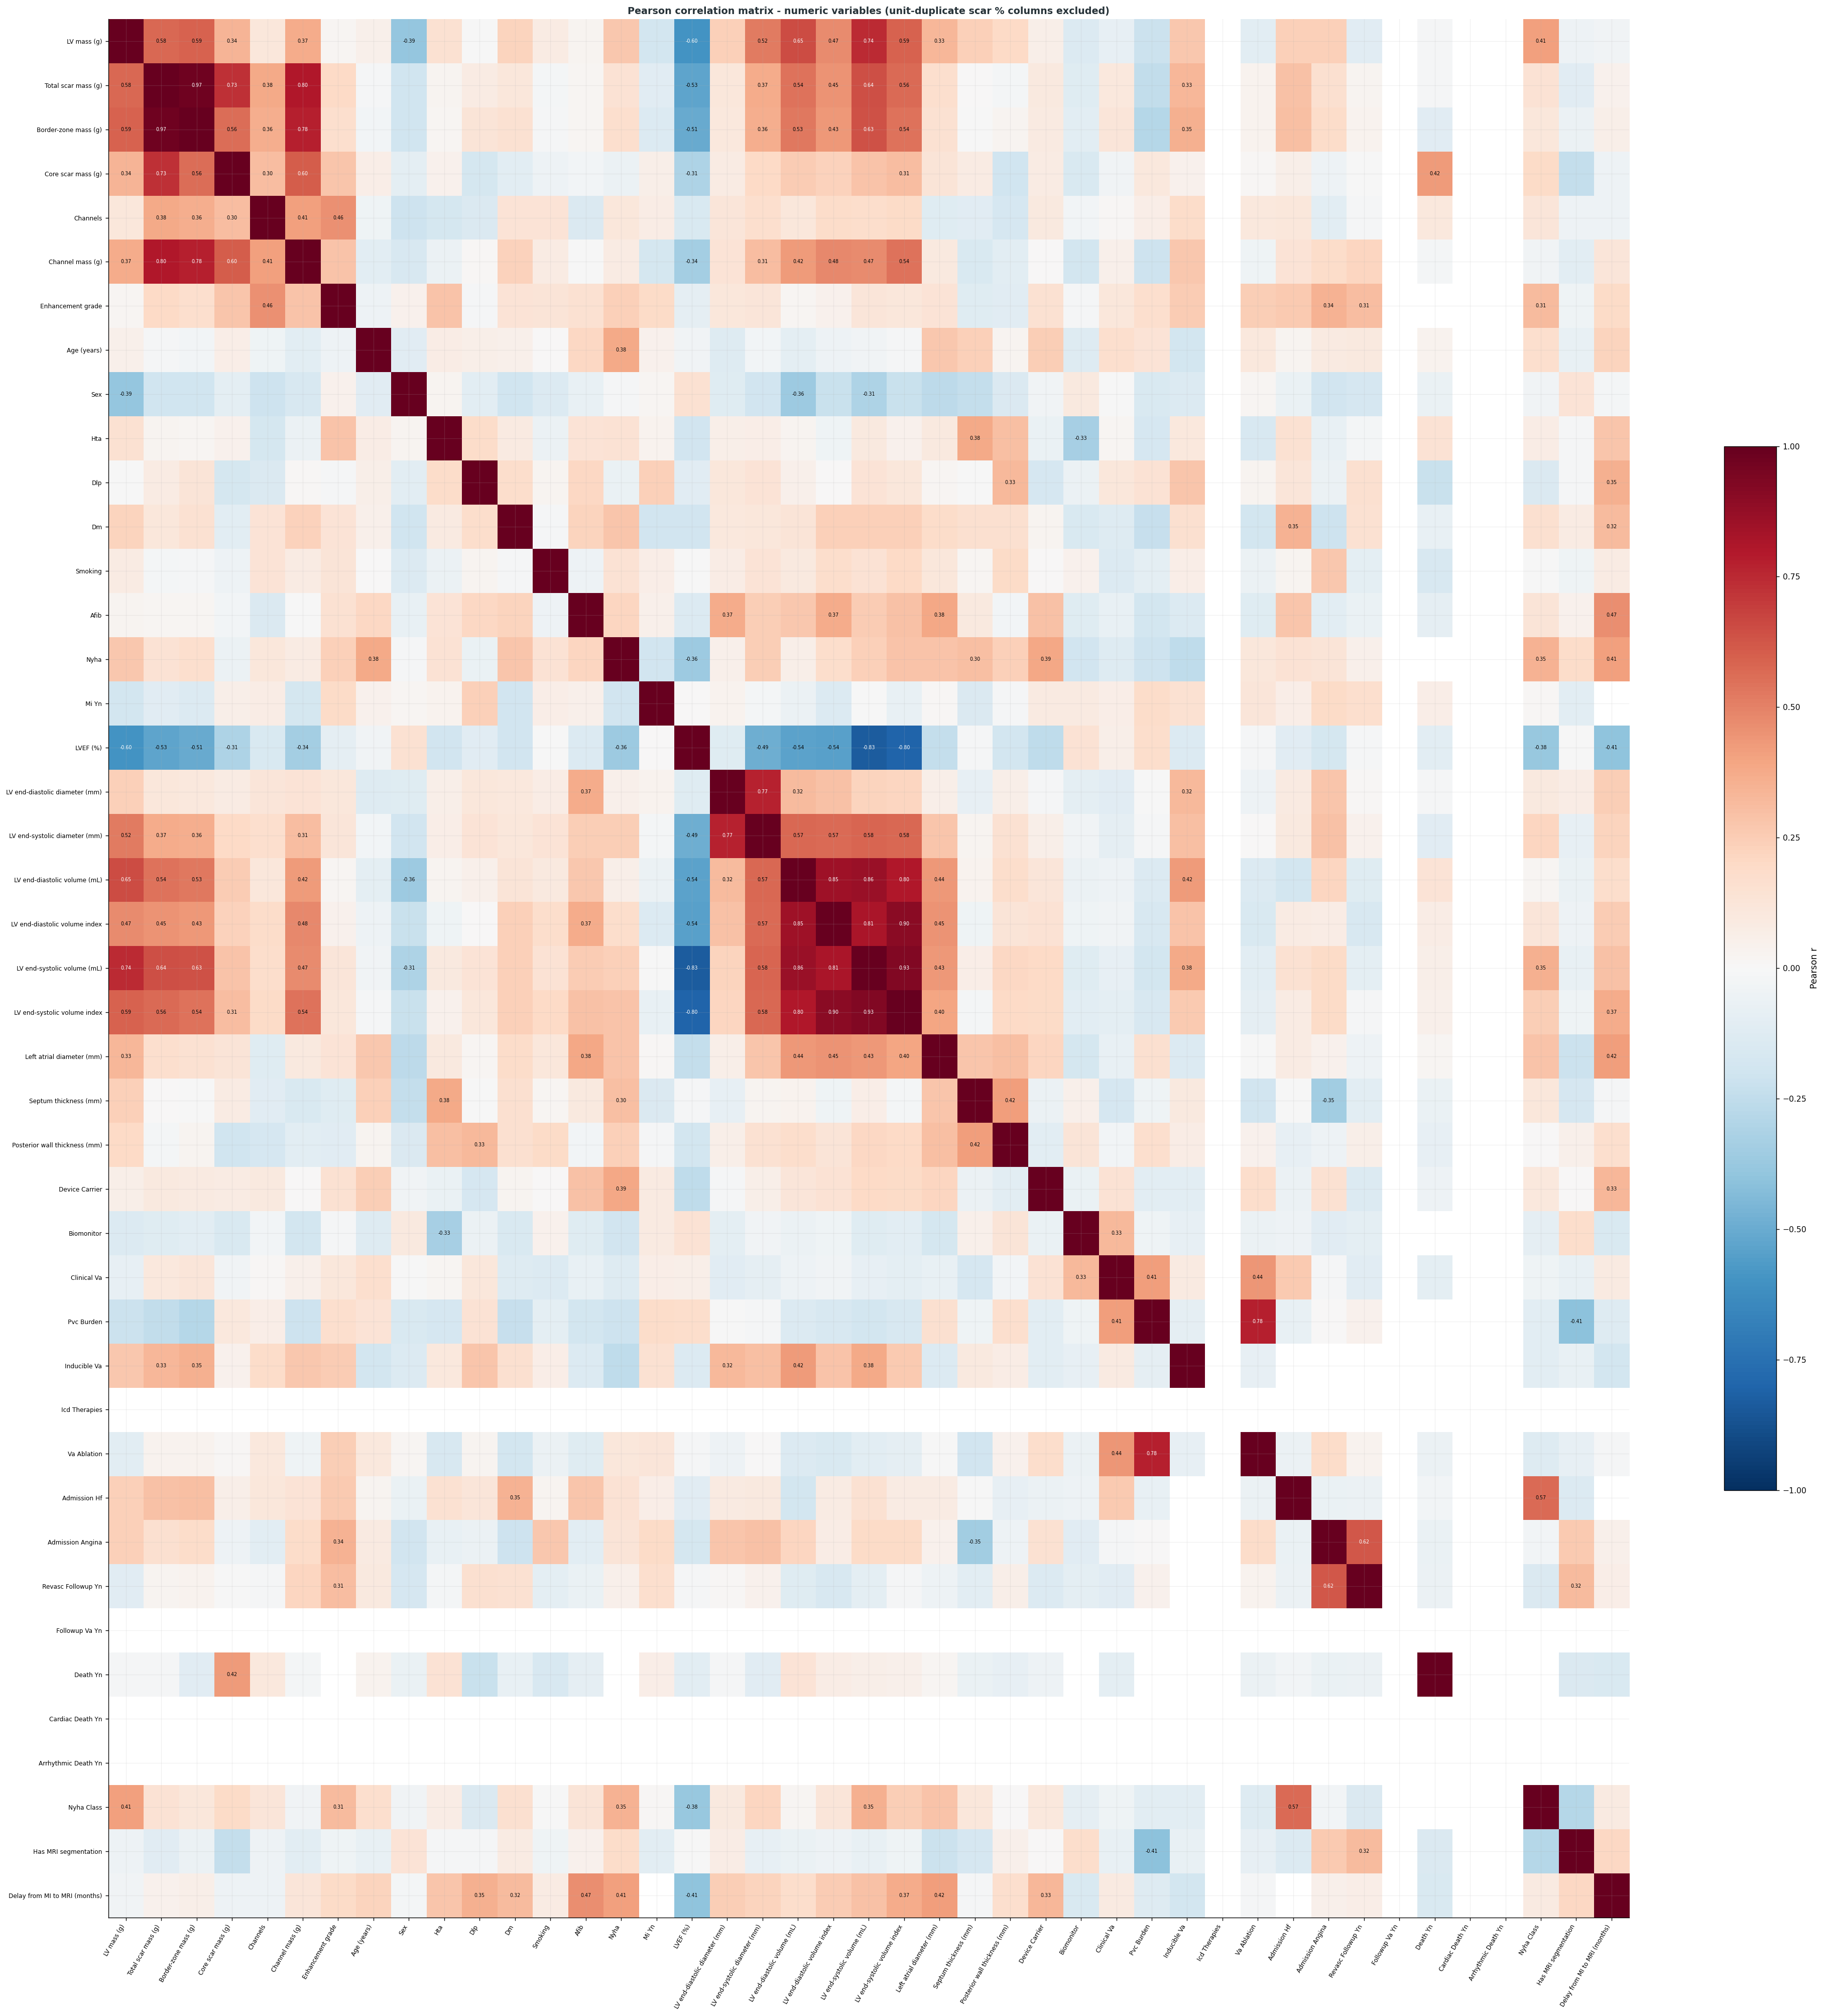

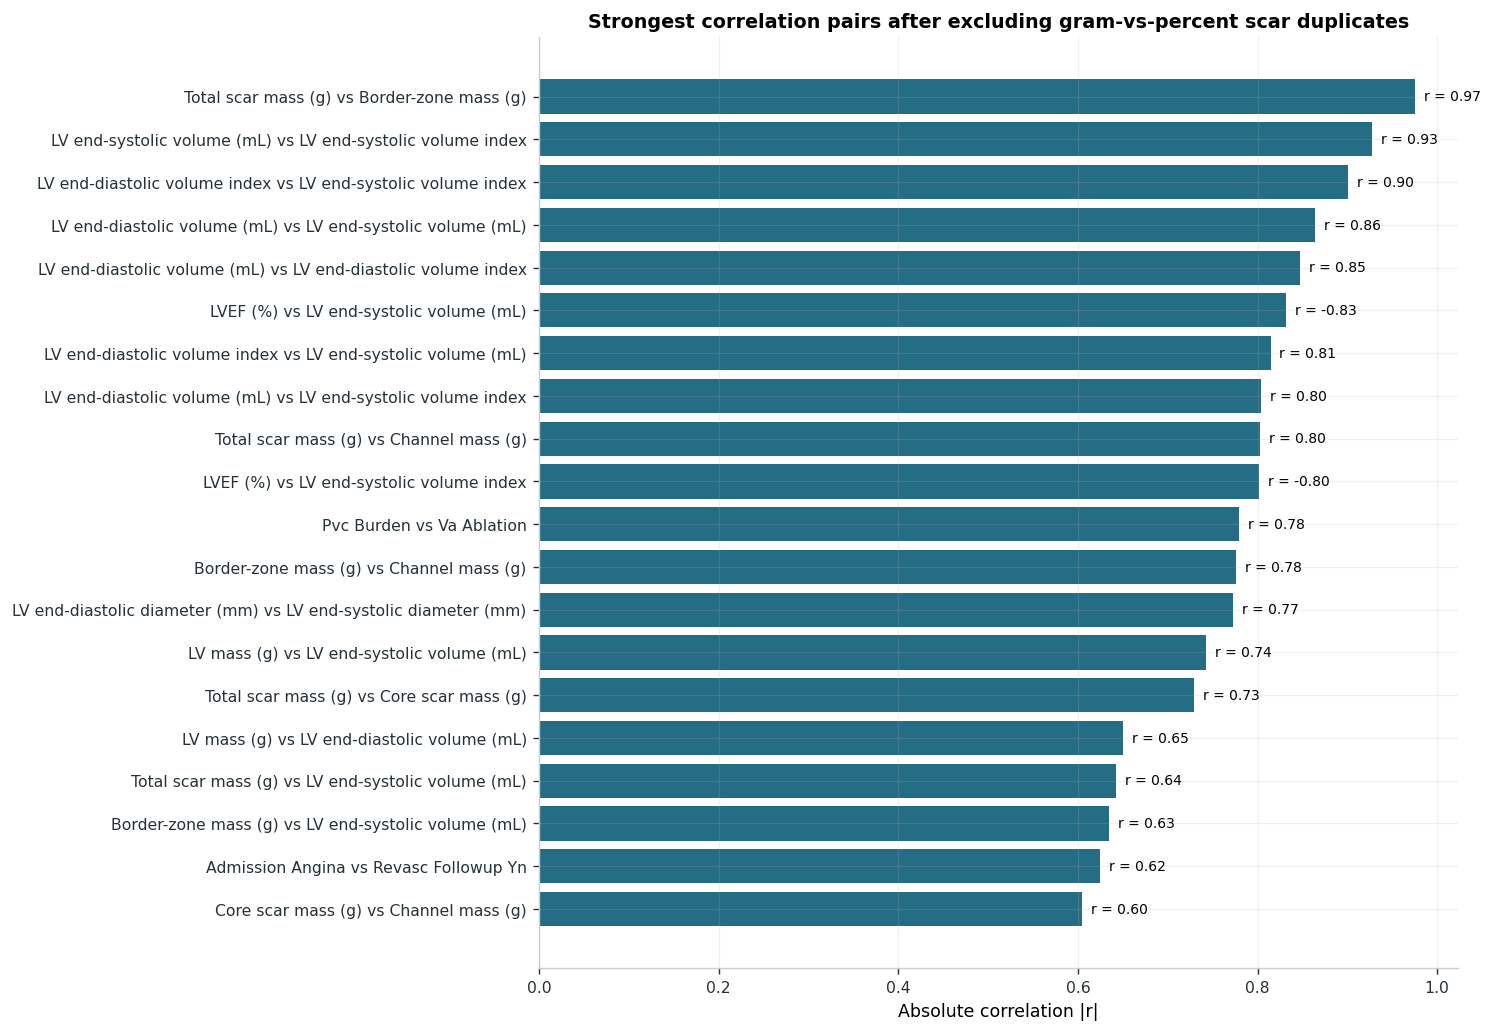

,Variable A,Meaning A,Variable B,Meaning B,r,abs_r
0,Total scar mass (g),Border zone + core scar mass in grams,Border-zone mass (g),Heterogeneous border zone mass in grams,0.974888,0.974888
1,LV end-systolic volume (mL),LV volume at end-systole,LV end-systolic volume index,Indexed LV end-systolic volume,0.927144,0.927144
2,LV end-diastolic volume index,Indexed LV end-diastolic volume,LV end-systolic volume index,Indexed LV end-systolic volume,0.900496,0.900496
3,LV end-diastolic volume (mL),LV volume at end-diastole,LV end-systolic volume (mL),LV volume at end-systole,0.864347,0.864347
4,LV end-diastolic volume (mL),LV volume at end-diastole,LV end-diastolic volume index,Indexed LV end-diastolic volume,0.846791,0.846791
...,...,...,...,...,...,...
1844,Va Ablation,,Septum thickness (mm),Interventricular septum thickness,NaN,NaN
1845,Va Ablation,,Sex,"Registry code: 1 = male, 2 = female",NaN,NaN
1846,Va Ablation,,Smoking,,NaN,NaN
1847,Va Ablation,,Total scar mass (g),Border zone + core scar mass in grams,NaN,NaN


In [19]:
SCAR_UNIT_COLUMNS_TO_EXCLUDE_FROM_MATRIX = {'bz_core_pct', 'core_pct', 'bz_pct'}
all_num_raw = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and df[c].notna().sum() >= 20 and c not in ('patient_id','patient_id_norm')]
all_num = [c for c in all_num_raw if c not in SCAR_UNIT_COLUMNS_TO_EXCLUDE_FROM_MATRIX]
print('Excluded from correlation matrix to avoid gram-vs-percent duplication:')
print([c for c in all_num_raw if c in SCAR_UNIT_COLUMNS_TO_EXCLUDE_FROM_MATRIX])
corr = df[all_num].apply(pd.to_numeric, errors='coerce').corr(method='pearson', min_periods=10)
short_labels=[variable_label(c) for c in all_num]; sz=max(12, len(all_num)*0.75); fig, ax=plt.subplots(figsize=(sz,sz)); im=ax.imshow(corr.values,cmap='RdBu_r',vmin=-1,vmax=1,aspect='auto')
ax.set_xticks(range(len(all_num))); ax.set_xticklabels(short_labels, rotation=60, ha='right', fontsize=7); ax.set_yticks(range(len(all_num))); ax.set_yticklabels(short_labels, fontsize=7); plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.55)
for i in range(len(all_num)):
    for j in range(len(all_num)):
        v=corr.iloc[i,j]
        if not np.isnan(v) and abs(v)>=0.3 and i!=j: ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=5.5,color='black' if abs(v)<0.6 else 'white')
ax.set_title('Pearson correlation matrix - numeric variables (unit-duplicate scar % columns excluded)', fontweight='semibold', color=TFG_COLORS['text']); plt.tight_layout(); plt.savefig(RESULTS_DIR / '05_correlation.png', bbox_inches='tight'); plt.show()
mask=np.triu(np.ones(corr.shape,dtype=bool),k=1); all_pairs=corr.where(mask).stack().reset_index(); all_pairs.columns=['var_a','var_b','r']; all_pairs['abs_r']=all_pairs['r'].abs(); all_pairs['Variable A']=all_pairs['var_a'].map(variable_label); all_pairs['Variable B']=all_pairs['var_b'].map(variable_label); all_pairs['Meaning A']=all_pairs['var_a'].map(variable_description); all_pairs['Meaning B']=all_pairs['var_b'].map(variable_description); all_pairs=all_pairs.sort_values(['abs_r','Variable A','Variable B'], ascending=[False,True,True]).reset_index(drop=True)
plot_pairs=all_pairs.head(min(20,len(all_pairs))).copy(); fig, ax=plt.subplots(figsize=(12,max(5,0.42*len(plot_pairs)))); ylabels=[f"{a} vs {b}" for a,b in zip(plot_pairs['Variable A'], plot_pairs['Variable B'])]; ax.barh(ylabels[::-1], plot_pairs['abs_r'].iloc[::-1], color=HIST_COLOR)
for i,r in enumerate(plot_pairs['r'].iloc[::-1]): ax.text(abs(r)+0.01, i, f'r = {r:.2f}', va='center', fontsize=8)
ax.set_xlabel('Absolute correlation |r|'); ax.set_title('Strongest correlation pairs after excluding gram-vs-percent scar duplicates'); apply_tfg_style(ax, xgrid=True); plt.tight_layout(); plt.savefig(RESULTS_DIR / '05_top_correlations.png', bbox_inches='tight'); plt.show()
display(all_pairs[['Variable A','Meaning A','Variable B','Meaning B','r','abs_r']]); all_pairs[['Variable A','Meaning A','Variable B','Meaning B','r','abs_r']].to_csv(RESULTS_DIR / '05_all_correlations_sorted.csv', index=False)

## 7 - Subgroup comparisons

We compare scar burden across clinical groups and also check practical age and LV-size questions.

Notes:
1. Age groups are defined from the dataset itself using tertiles (`pd.qcut`), so `Younger`, `Middle`, and `Older` are data-driven groups with similar patient counts.
2. `_pct` variables are already normalized by LV mass, while `_g` variables are absolute scar mass in grams.
3. To study age in more detail, we now plot total scar mass, core scar mass, and border-zone scar mass directly against age.


Age groups used in the plots (dataset tertiles):


,age_group_interval,n_patients
0,"(30.999, 61.0]",34
1,"(61.0, 68.667]",29
2,"(68.667, 84.0]",32


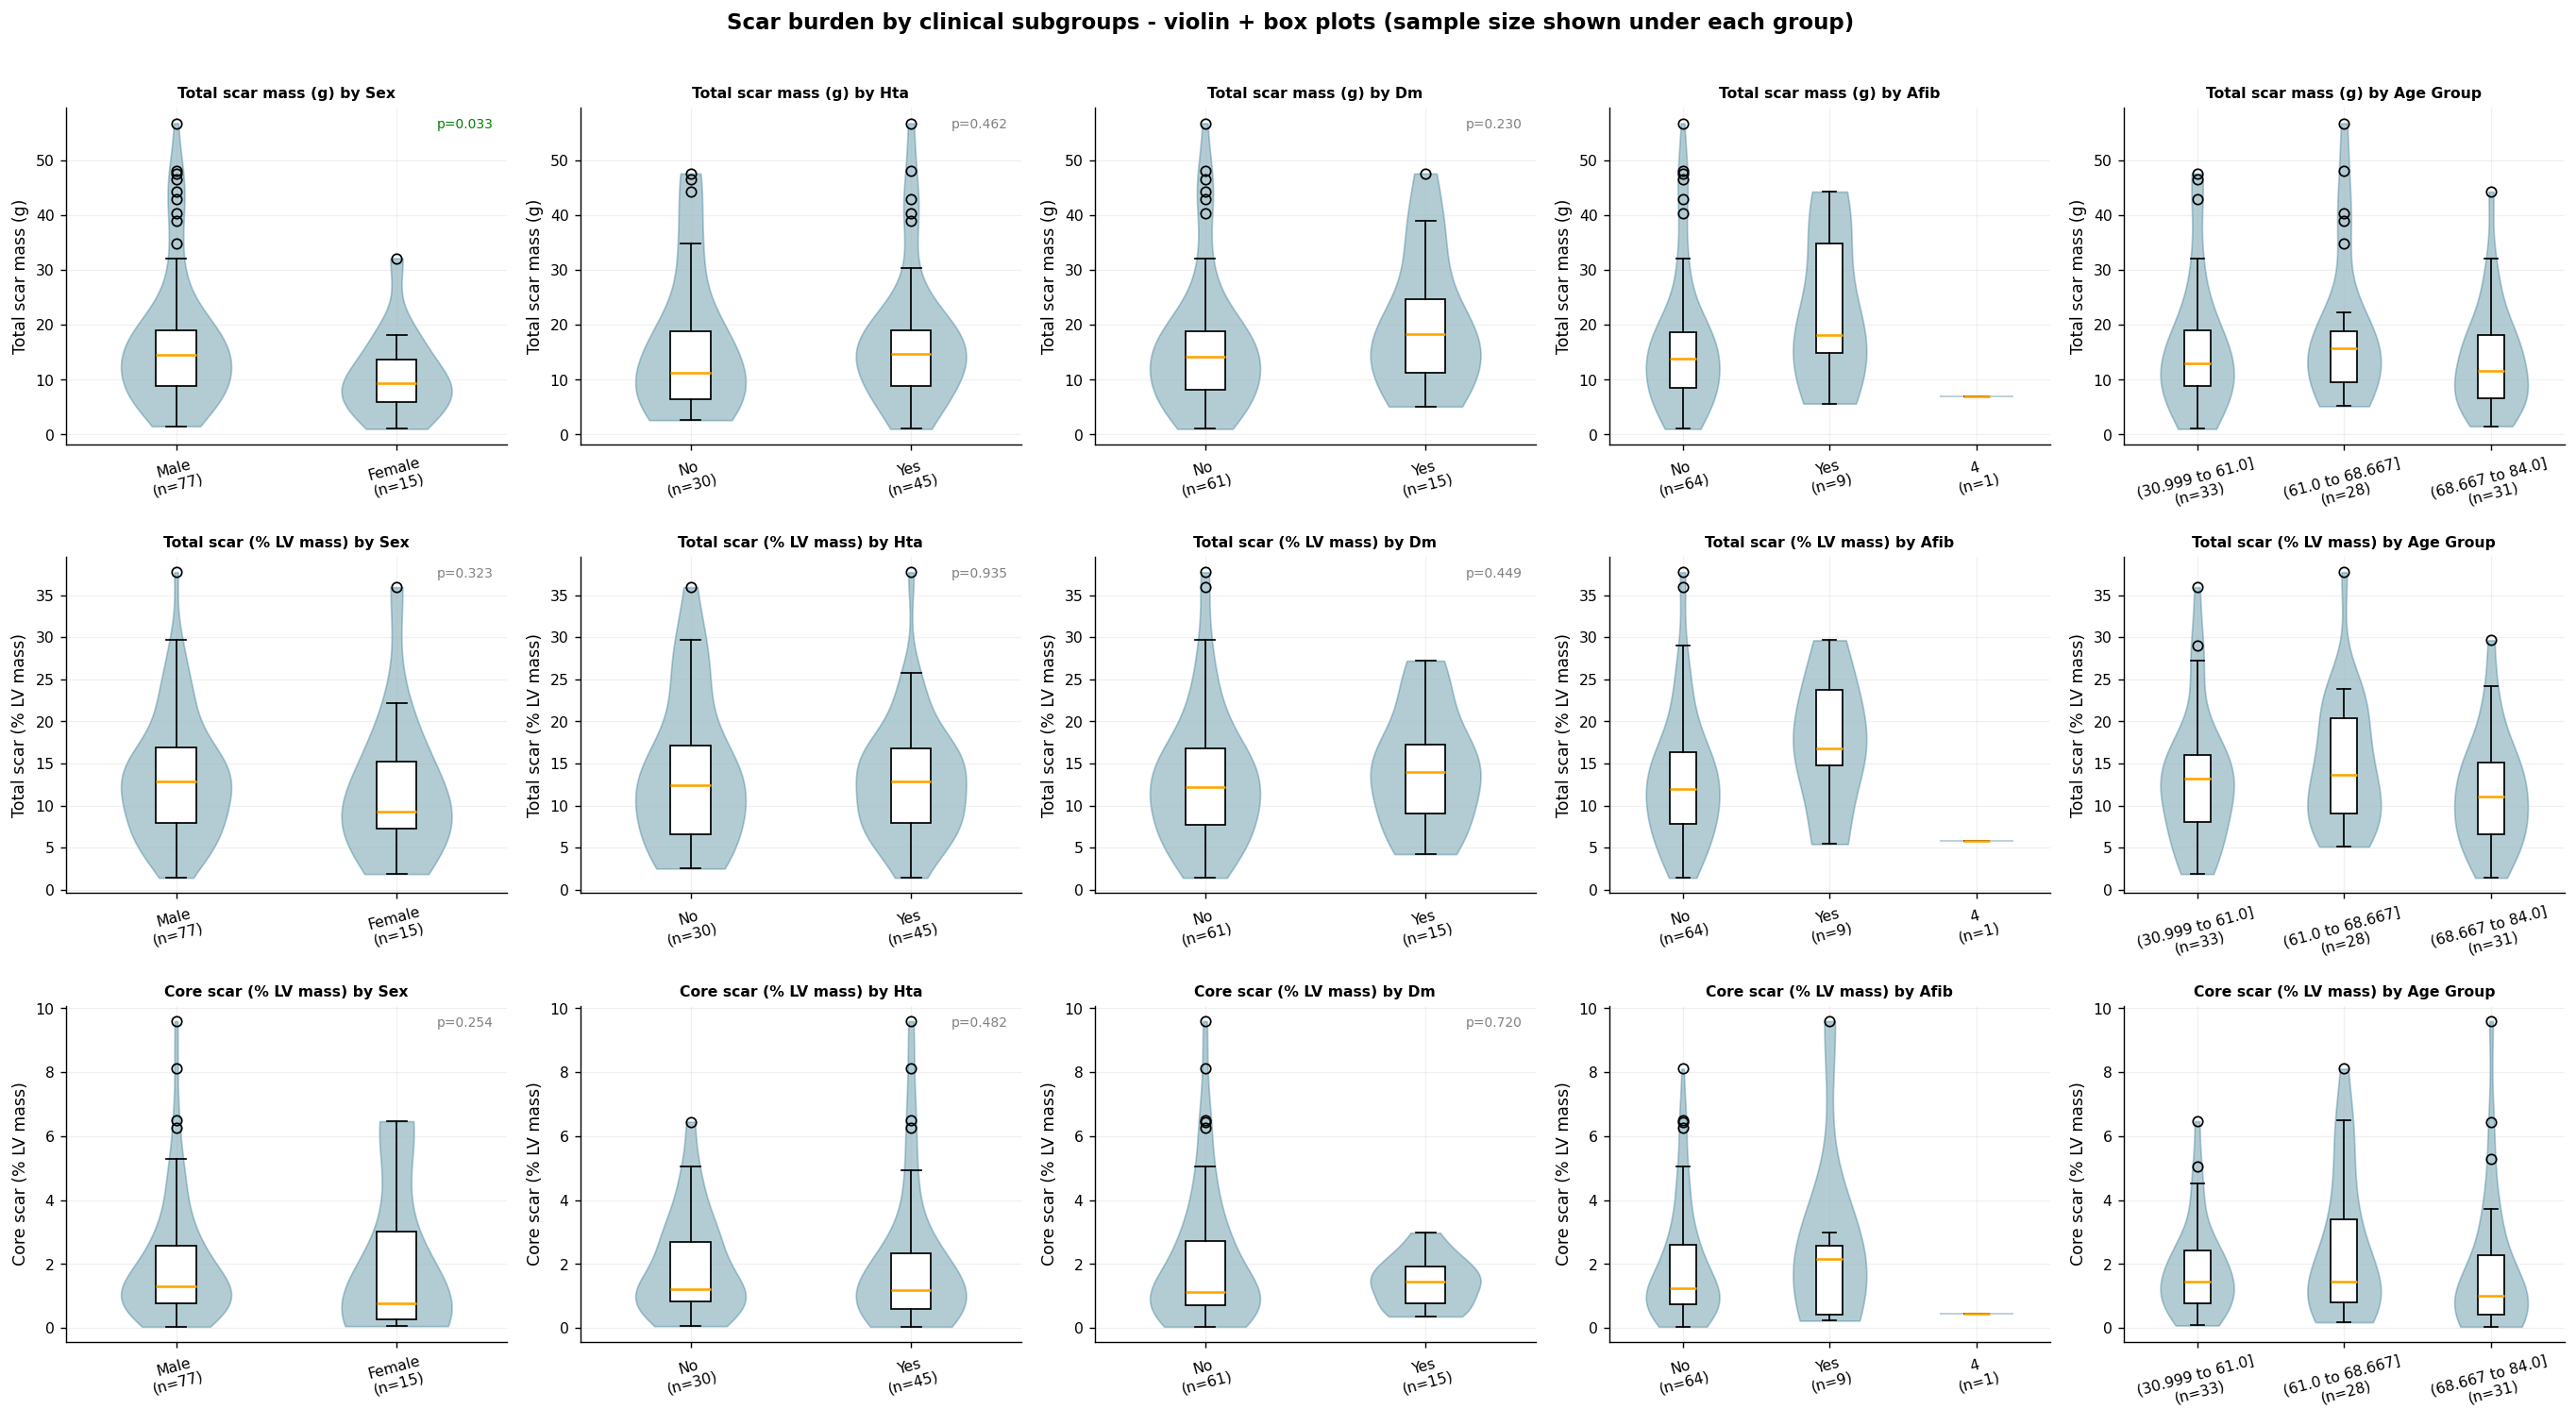

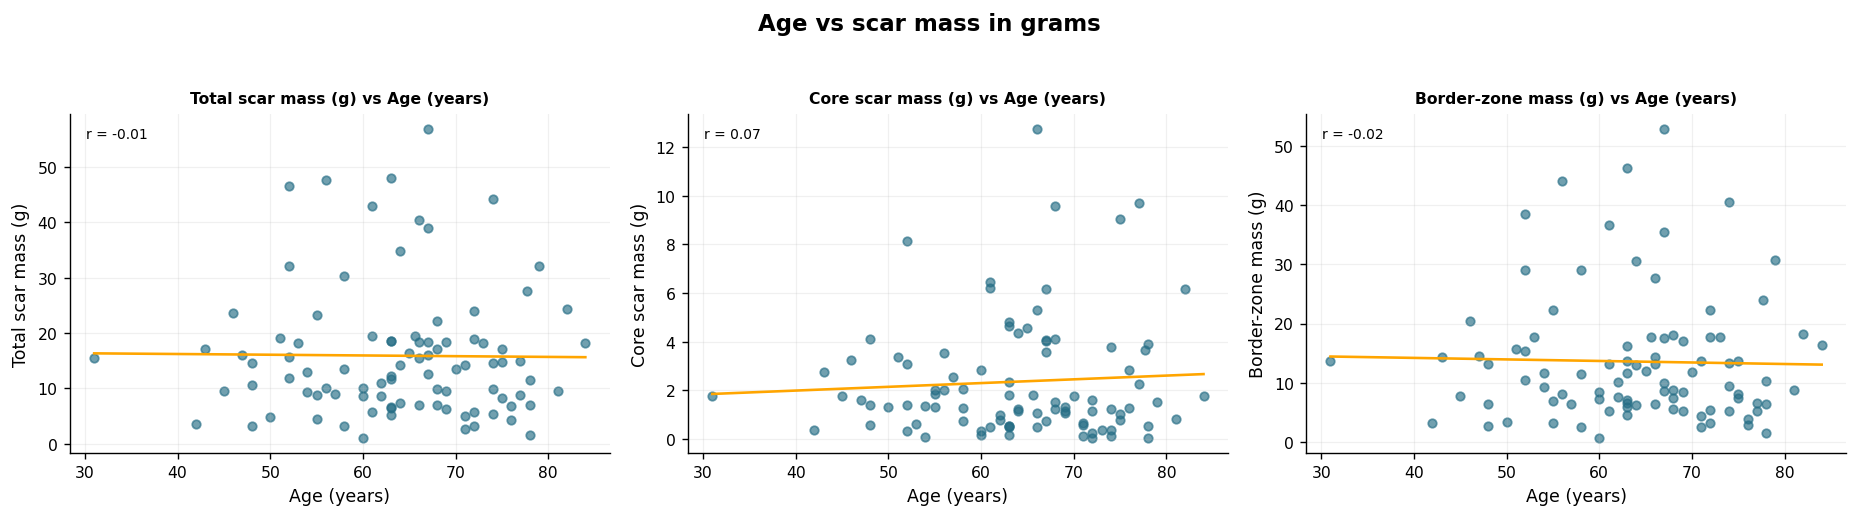

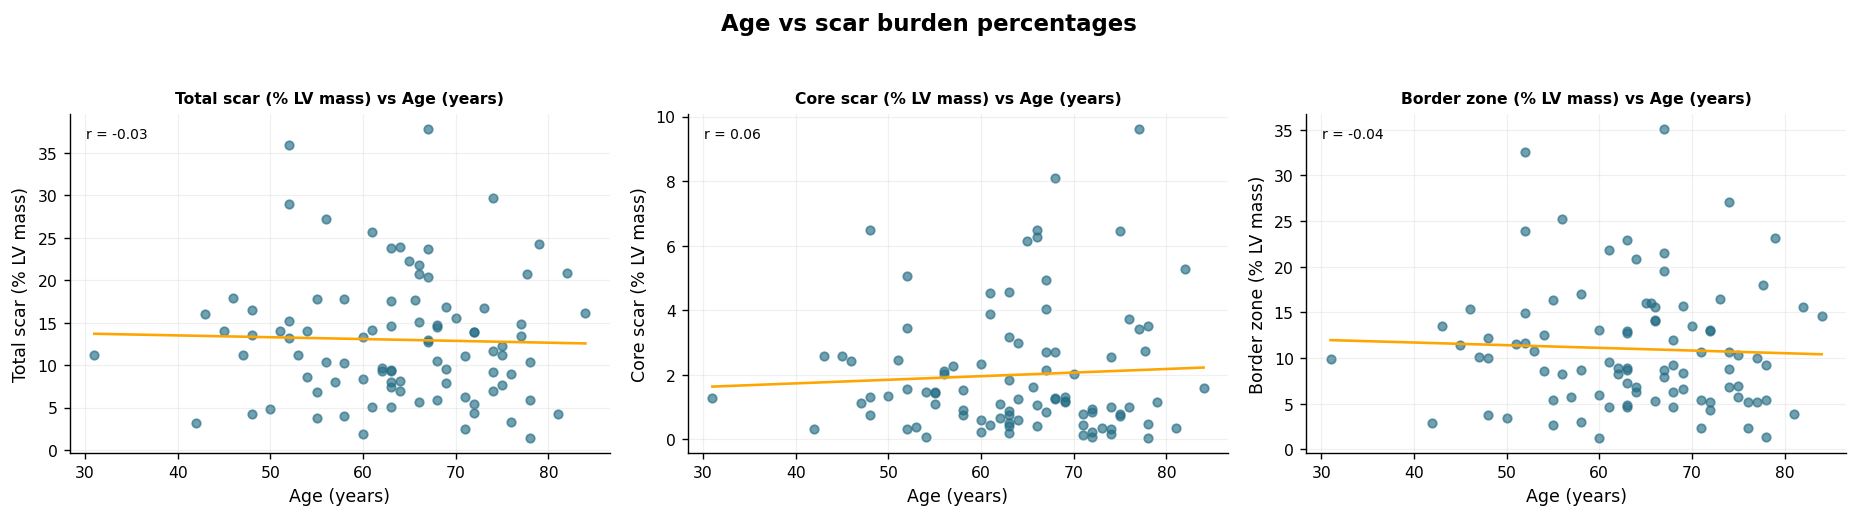

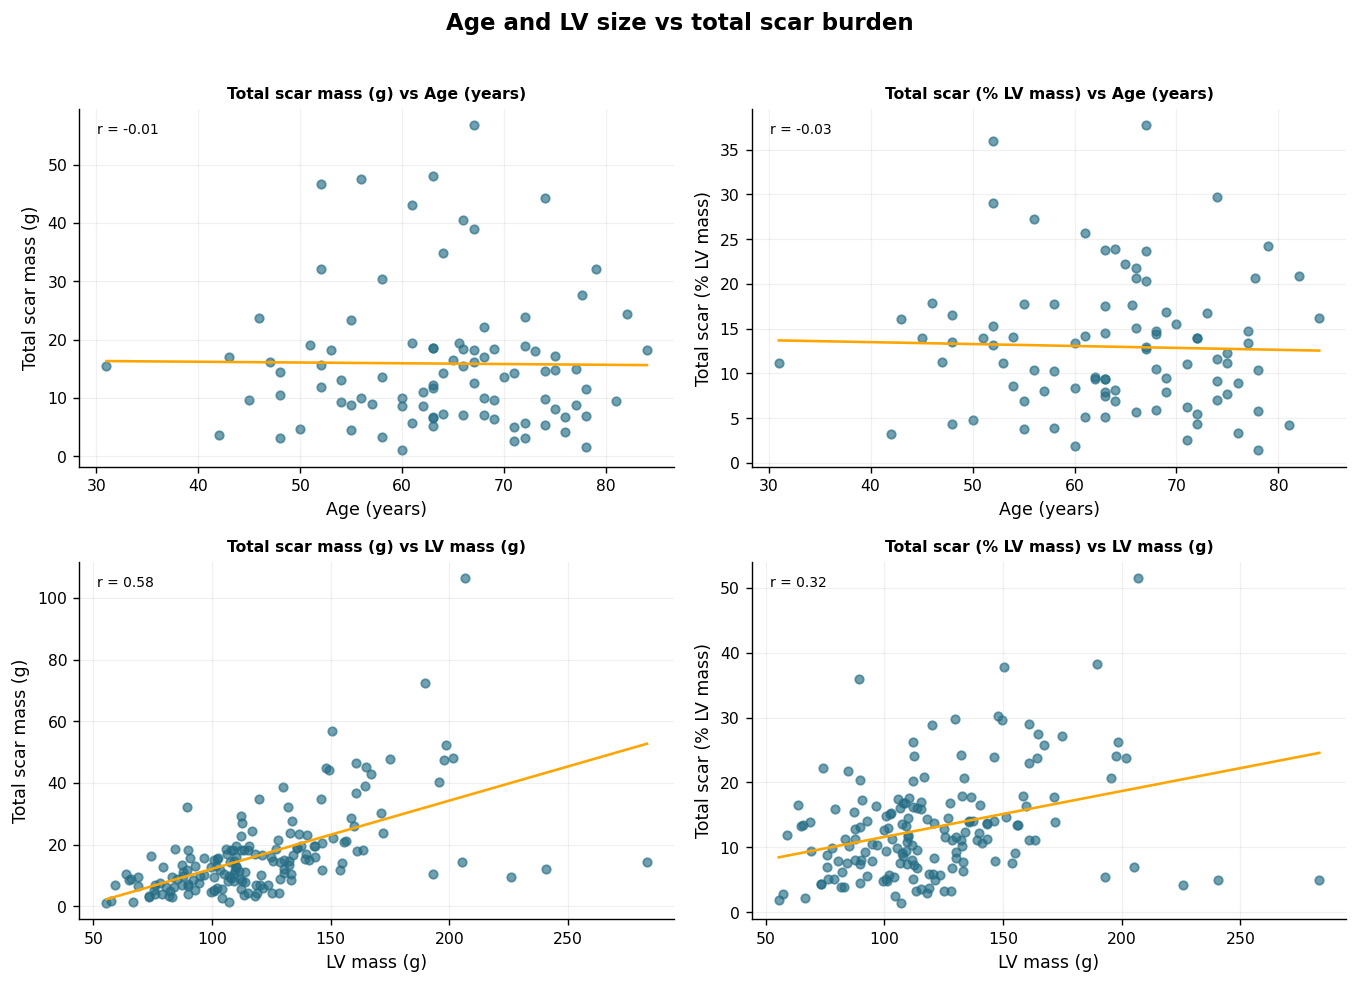

In [20]:
def boxplot_group(df, group_col, value_col, labels=None, ax=None, violin=False):
    sub = df[[group_col, value_col]].dropna()
    groups = sorted(sub[group_col].unique())
    data = [sub.loc[sub[group_col] == g, value_col].values for g in groups]
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    if not groups:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return ax
    positions = np.arange(1, len(groups) + 1)
    if violin:
        violin_parts = ax.violinplot(data, positions=positions, showmeans=False, showmedians=False, showextrema=False)
        for body in violin_parts['bodies']:
            body.set_facecolor(HIST_COLOR)
            body.set_edgecolor(HIST_COLOR)
            body.set_alpha(0.35)
    ax.boxplot(data, positions=positions, widths=0.18, patch_artist=True,
               medianprops=dict(color='orange', linewidth=1.5),
               boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.0),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'))
    tick_labels = []
    for g, vals in zip(groups, data):
        base_label = (labels or {}).get(g, str(g))
        tick_labels.append(f'{base_label}\n(n={len(vals)})')
    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, rotation=15)
    ax.set_ylabel(variable_label(value_col))
    ax.set_title(f'{variable_label(value_col)} by {variable_label(group_col)}', fontsize=9)
    if len(data) == 2 and min(len(d) for d in data) > 0:
        _, p = stats.mannwhitneyu(data[0], data[1], alternative='two-sided')
        ax.text(0.97, 0.97, f'p={p:.3f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8,
                color='green' if p < 0.05 else 'grey')
    return ax


def relation_plot(df, x_col, y_col, ax):
    sub = df[[x_col, y_col]].dropna().copy()
    if len(sub) < 3:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
        return
    x = pd.to_numeric(sub[x_col], errors='coerce')
    y = pd.to_numeric(sub[y_col], errors='coerce')
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    ax.scatter(x, y, color=HIST_COLOR, alpha=0.65, s=24)
    if len(x) >= 3:
        coeffs = np.polyfit(x, y, 1)
        xs = np.linspace(float(x.min()), float(x.max()), 100)
        ax.plot(xs, coeffs[0] * xs + coeffs[1], color='orange', linewidth=1.5)
        r = float(pd.Series(x).corr(pd.Series(y)))
        ax.text(0.03, 0.96, f'r = {r:.2f}', transform=ax.transAxes,
                ha='left', va='top', fontsize=8)
    xlab = variable_label(x_col)
    ylab = variable_label(y_col)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f'{variable_label(y_col)} vs {variable_label(x_col)}', fontsize=9)


age_group_labels = None
if 'age' in df.columns:
    valid_age = df['age'].dropna()
    age_bins = pd.qcut(valid_age, q=3, duplicates='drop')
    df.loc[valid_age.index, 'age_group'] = age_bins.astype(str)
    age_counts = df['age_group'].value_counts().sort_index()
    age_group_labels = {group: group.replace(',', ' to') for group in age_counts.index}
    age_group_summary = pd.DataFrame({
        'age_group_interval': age_counts.index,
        'n_patients': age_counts.values,
    })
    print('Age groups used in the plots (dataset tertiles):')
    display(age_group_summary)

scar_targets = [c for c in ['bz_core_g', 'bz_core_pct', 'core_pct'] if c in df.columns]
group_vars = [c for c in ['sex', 'hta', 'dm', 'afib', 'age_group'] if c in df.columns]
group_labels = {
    'sex': {1: 'Male', 2: 'Female'},
    'hta': {0: 'No', 1: 'Yes'},
    'dm': {0: 'No', 1: 'Yes'},
    'afib': {0: 'No', 1: 'Yes'},
    'age_group': age_group_labels or {},
}

if scar_targets and group_vars:
    fig, axes = plt.subplots(len(scar_targets), len(group_vars),
                             figsize=(4.4 * len(group_vars), 4.1 * len(scar_targets)))
    axes = np.array(axes).reshape(len(scar_targets), len(group_vars))

    for r, scar in enumerate(scar_targets):
        for c, grp in enumerate(group_vars):
            boxplot_group(df, grp, scar, labels=group_labels.get(grp), ax=axes[r, c], violin=True)

    plt.suptitle('Scar burden by clinical subgroups - violin + box plots (sample size shown under each group)', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.savefig(RESULTS_DIR / '07_subgroups.png', bbox_inches='tight')
    plt.show()

age_mass_cols = [('age', y) for y in ['bz_core_g', 'core_g', 'bz_g'] if 'age' in df.columns and y in df.columns]
if age_mass_cols:
    fig, axes = plt.subplots(1, len(age_mass_cols), figsize=(5.0 * len(age_mass_cols), 4.2))
    axes = np.atleast_1d(axes)
    for ax, (x_col, y_col) in zip(axes, age_mass_cols):
        relation_plot(df, x_col, y_col, ax=ax)
    plt.suptitle('Age vs scar mass in grams', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.savefig(RESULTS_DIR / '07_age_vs_scar_mass_components.png', bbox_inches='tight')
    plt.show()

age_pct_cols = [('age', y) for y in ['bz_core_pct', 'core_pct', 'bz_pct'] if 'age' in df.columns and y in df.columns]
if age_pct_cols:
    fig, axes = plt.subplots(1, len(age_pct_cols), figsize=(5.0 * len(age_pct_cols), 4.2))
    axes = np.atleast_1d(axes)
    for ax, (x_col, y_col) in zip(axes, age_pct_cols):
        relation_plot(df, x_col, y_col, ax=ax)
    plt.suptitle('Age vs scar burden percentages', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.savefig(RESULTS_DIR / '07_age_vs_scar_pct_components.png', bbox_inches='tight')
    plt.show()

relation_pairs = [
    ('age', 'bz_core_g'),
    ('age', 'bz_core_pct'),
    ('lv_mass_g', 'bz_core_g'),
    ('lv_mass_g', 'bz_core_pct'),
]
relation_pairs = [(x, y) for x, y in relation_pairs if x in df.columns and y in df.columns]

if relation_pairs:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, (x_col, y_col) in zip(axes.flatten(), relation_pairs):
        relation_plot(df, x_col, y_col, ax=ax)
    for ax in axes.flatten()[len(relation_pairs):]:
        ax.set_visible(False)
    plt.suptitle('Age and LV size vs total scar burden', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.savefig(RESULTS_DIR / '07_scar_relations_raw.png', bbox_inches='tight')
    plt.show()
